**<h1><center><b>User Manual: Volcano-Meteo-Tsurrogate</b></center></h1>

<font size=4>
    
<b>Authors:</b> Clea Denamiel  

<b>Version:</b> v1.0

<b>Publication Year:</b> 2026

</font>

----------------------------------------------------------

## INTRODUCTION
------------

Over the last decade, **surrogate modeling** approaches—**fast-running approximations** of computationally expensive dynamical models—have gained **increasing attention** in the geoscience community. By replacing large ensembles of numerical simulations with **efficient statistical representations**, surrogate models enable **rapid uncertainty quantification** while dramatically **reducing computational cost**. Unlike traditional sampling-based approaches (e.g., Monte Carlo simulations), surrogate models can be **trained once** for a given location and then **reused without additional high-performance computing resources**.

A **key strength** of surrogate models lies in their **flexibility and efficiency** under uncertainty. Their construction requires only **limited prior knowledge of uncertain parameters**, making them particularly suitable for applications where observations are sparse or poorly constrained. For instance, **uniform prior distributions** may be adopted when observational data are scarce, and **sparse sampling strategies** (such as sparse grids) can be used to **minimize the size of the training dataset**. These features make surrogate modeling a natural and practical choice for **probabilistic hazard assessment frameworks**.

In this context, surrogate models provide an effective foundation for **Probabilistic Meteotsunami Hazard Assessment (PMTHA)**. Here, uncertainties associated with atmospheric forcing are propagated through the modeling chain to quantify the probability that defined **meteotsunami hazard metrics**—such as **maximum elevation, current speed, or arrival time**—are exceeded along coastlines worldwide.

### Planetary meteotsunamis and volcanic forcing

**Planetary-scale meteotsunamis** driven by **volcanic eruptions** are rare events, generated only by the most energetic explosive eruptions (Fig. 1). These exceptional explosions can produce **atmospheric acoustic–gravity waves** strong enough to force ocean responses across **entire ocean basins**. Among these waves, **Lamb waves** play a central role. Propagating at nearly the **speed of sound (∼318 m.s⁻¹)**, Lamb waves can **circle the Earth multiple times** and trigger **meteotsunamis** far from their source.

Explosive volcanic eruptions act as **mechanical oscillators**: **vertical air motion** within eruption plumes, as well as **pulsations from intense heat release**, generate **atmospheric pressure disturbances**. The **amplitude and shape** of the resulting pressure pulses can be **related analytically to the erupted ejecta volume** and, by extension, to the **Volcanic Explosivity Index (VEI)**. The VEI provides a **logarithmic measure of eruption magnitude (0–8)** based primarily on ejecta volume. However, **large uncertainties persist**, as both VEI estimates and associated Lamb wave characteristics are often **poorly constrained**, particularly for eruptions with **limited instrumental observations**.

<center><img src="figures/JN_UM_figure_1.jpg" alt="Drawing" style="width: 600px;"/></center>

**Figure 1.** State-of-the-art of volcano-driven explosion-atmosphere-ocean dynamics and coastal hazards: near-field characterization of the Lamb wave pulse and far-field atmosphere-ocean dynamics.

### Modeling challenges from source to far field

Quantifying the **near-field Lamb wave pulse (Fig. 1)** requires detailed **numerical modeling of explosive volcanic eruptions**. Previous studies have demonstrated that both **one- and three-dimensional models** can capture plume dynamics across a wide range of eruption strengths. Strong plumes may penetrate the stratosphere, depart from self-similar turbulent behavior, and induce **substantial perturbations of atmospheric stratification**, including shock formation and gravity-driven particle currents in the umbrella region. Despite progress in modeling plume dynamics and their atmospheric impacts, a **fundamental question remains unresolved**: **why do only some eruptions generate Lamb waves that propagate globally?**

In contrast, the **far-field dynamics of volcano-driven meteotsunamis (Fig. 1)** can be simulated using **state-of-the-art atmosphere–ocean models**. In the atmosphere, **Lamb wave propagation** can be adequately represented using **barotropic models**. In the ocean, offshore **meteotsunami amplification** primarily arises from **partial Proudman resonance** in deep water and the **inverse barometer effect**, both of which scale with the amplitude of the atmospheric pressure disturbance. As a result, **existing tsunami and meteotsunami solvers** can be directly applied to simulate the oceanic response.

Although **planetary meteotsunamis** are a **secondary hazard** compared to the immediate impacts of explosive eruptions (such as ballistic ejecta, blast waves, ash clouds, gas emissions, or landslide-generated tsunamis), they can nonetheless **produce coastal surges of several meters along coastlines worldwide**. Despite their potentially global reach, these events remain **poorly quantified**. Much of the existing literature focuses on single-event reconstructions—most notably the Hunga Tonga–Hunga Haʻapai eruption—rather than systematic hazard assessment. To **move beyond isolated case studies** and support **integration into early warning systems**, a **cost-effective, lightweight, and scalable modeling framework** is required.

### Purpose of Volcano-Meteo-Tsurrogate v1.0

The **Volcano-Meteo-Tsurrogate v1.0 software** has been developed to address this need. Its primary objective is to provide **faster-than-real-time forecasts of meteotsunami waves** following explosive volcanic eruptions. Because **large eruptions (VEI ≥ 5)** are rare, the surrogate models implemented in this framework are **trained entirely on deterministic numerical simulations**. To overcome the high computational cost of coupled atmosphere–ocean models, the software employs a **stochastic surrogate modeling strategy based on generalized Polynomial Chaos Expansion (gPCE)**.

This approach enables **efficient uncertainty propagation**, as statistical moments and sensitivity indices can be directly derived from the gPCE coefficients. The **validity** of using surrogate models in this context relies on the **convergence of the gPCE representation** for key hazard metrics (**maximum elevation, maximum current speed, and arrival time**). This assumption has previously been **validated for meteotsunami hazards driven by atmospheric disturbances in the Adriatic Sea** and forms the basis for its **extension to volcano-driven planetary meteotsunamis**.

### Scope of this user manual

This **Jupyter Notebook** serves as the **User Manual for Volcano-Meteo-Tsurrogate v1.0**. It documents the **complete workflow for constructing surrogate models** of volcano-generated meteotsunamis, from **defining stochastic inputs** to **performing probabilistic hazard assessments**. 

Throughout the document, the symbol ***<font color='green'>@user</font>*** indicates that the user should perform an action.

The **methodology** is illustrated using **11 representative volcanoes worldwide (Fig. 2)**: 
- Askja (65.0111°N, -16.7485°E) and Katla (63.6467°N, -19.1303°E) in Iceland,
- Vesuvius (40.8224°N, 14.4289°E) and Campi Flegrei (40.8270°N, 14.1390°E) in Italy,
- Mount Saint Helens (46.1914°N, -122.1956°E) and Yellowstone (44.4123°N, -110.7232°E) in USA,
- Cotopaxi (-0.6838°N, -78.4372°E)  in Ecuador,
- Popocatépetl (19.0224°N, -98.6279°E) in Mexico,
- Hunga Tonga–Hunga Ha’apai (HTHH; -20.5700°N, -175.3800°E) in Tonga,
- Mount Pinatubo (15.1429°N, 120.3496°E) in Philippines,
- Mount Sakurajima (31.5833°N, 130.6500°E) in Japan.

<center><img src="figures/JN_UM_figure_2.jpg" alt="Drawing" style="width: 800px;"/></center>

**Figure 2.** Geographycal locations of the 11 studied volcanoes. 

The surrogate model construction follows seven clearly defined steps, each implemented as a dedicated Python program within the Volcano-Meteo-Tsurrogate v1.0 software (Fig. 3):

**STEP 1**: Stochastic variables, mathematical framework and sampling functions 

**STEP 2**: Parameters for the deterministic simulations

**STEP 3**: Deterministic simulation runs

**STEP 4**: Simulation output formatting

**STEP 5**: Coefficient of the gPCE

**STEP 6**: Convergence, performance and sensitivity 

**STEP 7**: PMTHA

### Structure of the Volcano-Meteo-Tsurrogate software

In practice, the **Volcano-Meteo-Tsurrogate v1.0 software** is implemented with **dedicated user-oriented Python programs** following the constructions steps (**except step 3**). The software follows a **simple structure (Fig. 3)**. To run the model, three folders are required: **code, data, and results**.

<img src="figures/JN_UM_figure_3.jpg" alt="Drawing" style="width: 400px;"/>

**Figure 3.** Structure of the Volcano-Meteo-Tsurrogate v1.0 software.

The **code folder** contains the **seven user-oriented programs** that each produce a **single MATLAB-format output file**. They should be **executed sequentially** following the workflow presented in **Figure 4**. While each program can run independently, it depends on input files generated by the preceding step. This modular structure is intentional, as certain steps—such as running deterministic simulations—require user intervention and can be time-consuming. Separating the programs in this way allows for **greater flexibility and practicality in managing the workflow**.

<img src="figures/JN_UM_figure_4.jpg" alt="Drawing" style="width: 400px;"/>

**Figure 4.** Workflow pipeline of the main programs and associated functions in Volcano-Meteo-Tsurrogate v1.0 for the generation of the surrogate models. User-oriented programs are shown in Blue boxes, core building-block functions in Orange, and supporting functions in Green and Yellow. Functions or programs that require user editing are highlighted in Grey. The input/output flow between components is represented by arrows, labeled with the names of the variables saved in the corresponding files.

The **data folder** includes **input files** that the user must generate outside the Volcano-Meteo-Tsurrogate v1.0 software. The description of these files is provided in step 3. 

Finally, the **MATLAB-format output files** of the seven main programs are created in the **results folder**.

***<font color='green'>@user Make sure that all the required libraries are installed on your machine, then Run the cell below to import all libraries needed to run the notebook</font>***

In [ ]:
%matplotlib widget
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import os
import time
import plotly.graph_objects as go
import mplcursors
import gdown
from scipy.stats import gaussian_kde
from scipy import interpolate as interp
from scipy.integrate import quad
from math import comb, exp
from plotly.subplots import make_subplots
from pathlib import Path as pth
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

----------------------------------------------------------
## STEP 1: STOCHASTIC VARIABLES, MATHEMATICAL FRAMEWORK & SAMPLING FUNCTIONS 
----------------------------------------------------------

### 1) STOCHASTIC VARIABLES & MATHEMATICAL FRAMEWORK

In the **Volcano-Meteo-Tsurrogate model**, to capture the **uncertainty of meteotsunami surges (i.e., maximum elevation) and their associated maximum speed** in the aftermath of explosive eruptions, a **synthetic atmospheric pressure disturbance** that represent the **Lamb waves** generated by the blast is prescribed. This simplified forcing is necessary because **direct modeling** of the coupled **explosion–atmosphere–ocean** process is computationally **expensive and not yet state-of-the-art** as the physical mechanisms remain only partially constrained. In the presented test cases, the disturbances are modeled with **idealized traveling pressure pulses, parameterized by four stochastic variables $(n_s=4)$ depending on a set of elementary events $(\omega \in \Omega)$**—amplitude at the epicenter **$P_0(\omega)$**, propagation speed **$c(\omega)$**, wavelength **$\lambda(\omega)$**, and temporal attenuation **$\tau(\omega)$**—which capture the principal sources of uncertainty in atmospheric dynamics (Eq. [1]):

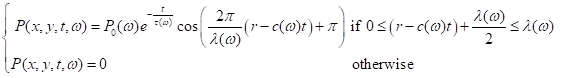


with $(x,y,t)$ the spatio-temporal referential and $r$ the distance to the volcanic eruption epicenter.

Given the scarcity of observations and the incomplete understanding of explosion–atmosphere–ocean interactions, the **four stochastic variables are assumed to be mutually independent and uniformly distributed**. Within the bounds of these distributions, any acoustic-gravity wave is considered equally probable. The limits of each uniform distribution are chosen to encompass the **full range of physically plausible conditions** capable of triggering planetary meteotsunamis. Both the use of uniform distributions and the assumption of independence are justified by the **maximum entropy principle**, which dictates that, in the presence of limited information, the distribution with the highest entropy—i.e., based on the fewest assumptions—should be preferred. Within this framework, the prior distributions of the stochastic variables are defined as follows in the presented test cases (Eq. [2]):

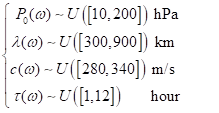

The **gPCE mathematical framework** of the **Volcano-Meteo-Tsurrogate v1.0** model is based on **polynomial expansions** that decompose into **deterministic coefficients** and random **orthogonal bases**. For the **uniform distributions**, the appropriate orthogonal bases are **Legendre polynomials** (note: if other distributions are used, different types of orthogonal polynomials should be selected accordingly).

The **deterministic coefficients**—which represent the projection of meteotsunami maximum elevation, maximum speed, and time of arrival onto each polynomial basis—are computed using a **quadrature-based approximation** derived from **deterministic numerical simulations**. These simulations are defined by sampling the parameter intervals described above, and the number of required samples depends on the chosen **maximum polynomial degree of the Legendre polynomials** and the **quadrature rule chosen**.


The **deterministic coefficients** represent the projection of meteotsunami maximum elevation, maximum speed, and time of arrival onto each polynomial basis. However, in the **absence of analytical formulations**, numerical integration methods are employed to approximate these projections. One common method for **computing multidimensional integrals** is to express them as a series of nested one-dimensional integrals using **Fubini’s theorem (also known as the tensor product rule)**. However, this technique leads to an **exponential increase** in the number of required function evaluations—and thus, in the presented context, the **deterministic volcano-meteotsunami simulations**—as the number of dimensions grows, a phenomenon known as the **curse of dimensionality**. To address this issue, three main alternative methods have been developed to **mitigate the computational burden**: the **Monte Carlo**, **Sparse Grids** and **Bayesian Quadrature** methods. In **Volcano-Meteo-Tsurrogate v1.0** the deterministic coefficients are computed using a **quadrature-based approximation** derived from **deterministic volcano-meteotsunami numerical simulations**. These simulations are defined by sampling the parameter intervals described above, and the number of required samples depends on the chosen **maximum polynomial degree** of the Legendre polynomials and the **quadrature rule** chosen. The **higher the polynomial degree**, the **greater the number of samples**, and thus, the **larger the number of deterministic simulations** that must be performed. For the presented **11 volcanoes**, the **maximum polynomial degree or total order** used is **6**.

The above distributions give the parameters used in **Volcano-Meteo-Tsurrogate v1.0** to create the surrogate models for the **11 volcanoes**. These parameters should **not be modified** unless the user intends to run deterministic meteotsunami simulations for different study cases (other volcanoes and/or other synthetic formulations).

### 2) SAMPLING FUNCTIONS

In **Volcano-Meteo-Tsurrogate v1.0**, the **sampling of the uniform distributions** and, hence, the selection of an **appropriate quadrature rule**, is critical as it determines both the **accuracy of the surrogate models** and the total **number of deterministic volcano-meteotsunami simulations** to be performed. Among the most used quadrature rules for uniform distributions are the **Gauss–Legendre, Clenshaw–Curtis, and Gauss–Patterson rules**. 

The **Gauss–Legendre quadrature** is the **standard rule** for uniform distributions, offering **exact integration** for any polynomial of degree. However, a **key limitation** of the Gauss–Legendre rule is that its **samples or abscissas are not nested**—i.e., the points used in the n-point rule (corresponding to n volcano-meteotsunami simulations) are entirely different from those in the (n − 1)-point rule, **preventing reuse of previous simulations**.

In contrast, **nested quadrature rules** allow the abscissas of a lower-order rule to be included in higher-order ones, which significantly **enhances computational efficiency**.  In nested rules, the concept of **level** is introduced to denote the quadrature rule where the abscissas are nested. Practically, this means that **all deterministic simulations required at a given level $l$ are also used at level $l+1$**. As a result, **surrogate models** can be progressively **upgraded over time**, which is especially beneficial if the user lacks the numerical resources to run all high-order simulations at once.

The **Clenshaw–Curtis and Gauss–Patterson rules** are the most frequently used nested quadrature rules for uniform distributions. The main difference between these two lies in their precision and growth rate: the **Gauss–Patterson rule** typically provides nearly **double the accuracy and point growth** compared to the Clenshaw–Curtis rule. At **level $l$**, the **number of abscissas** required is **$2^l+1$ for Clenshaw–Curtis** and **$2^{l+1}-1$ for Gauss–Patterson**. To make **Gauss–Patterson rules more efficient**—by **limiting** the rapid growth in the number of abscissas and, hence, the **number of volcano-meteotsunami simulations**—the introduction of successive quadrature levels can be **delayed**. This **delayed Gauss–Patterson rule** uses a **reduced set of abscissas** while **preserving high integration accuracy**. Consequently, this approach significantly reduces the number of required quadrature points without sacrificing the quality of the surrogate model.

In **Volcano-Meteo-Tsurrogate v1.0**, only the **Gauss–Patterson (GP) and delayed Gauss–Patterson (DGP) quadrature rules** are implemented, as they offer greater precision than the Clenshaw–Curtis rule. The **functions below** constitute the **core building blocks** used to sample the intervals, following the Gauss–Patterson and delayed Gauss–Patterson sparse nested grid rules.


***<font color='green'>@user Have a look at the functions and test them to understand how they work</font>***

*******************************
**Gauss–Patterson 1-dimensional quadrature rule (gauss_patterson_nested_rule_1d)**
*******************************

The **Gauss–Patterson quadrature rule** is a nested extension of Gauss–Legendre quadrature. It starts from the **Gauss–Legendre rules of levels 0 and 1** and successively **inserts new abscissas into existing subintervals**.

As a result, Gauss–Patterson rules **sacrifice some of the ultra-high precision** of Gauss–Legendre quadrature in exchange for **nestedness**, which is essential for **sparse-grid and adaptive integration technique**s.
Gauss–Patterson rules are only defined for levels 0 to 8, corresponding to the following numbers of abscissas: 1, 3, 7, 15, 31, 63, 127, 255, 511.

The **level-0 (1 point)** and **level-1 (3 points)** rules coincide with the standard **Gauss–Legendre rules**. From **level 2 onward**, each rule contains **all abscissas from the previous levels**, ensuring strict nestedness.

The **Gauss–Patterson quadrature** is based on the following literature:

- Prem Kythe, Michael Schaeferkotter, Handbook of Computational Methods for Integration, Chapman and Hall, 2004,ISBN: 1-58488-428-2, LC: QA299.3.K98.
- Thomas Patterson, The Optimal Addition of Points to Quadrature Formulae,Mathematics of Computation,Volume 22, Number 104, October 1968, pages 847-856.

The **supporting function gauss_patterson_nested_rule_1d (Fig. 4)** constructs the abscissas and weights of a one-dimensional Gauss–Patterson quadrature rule on a user-defined interval.

***<font color='green'>@user Check the function below and run the cell to upload it in the notebook</font>***

In [ ]:
def gauss_patterson_nested_rule_1d(n, a, b):
    """
    :param n: Number of points (must be 1, 3, 7, 15, 31, 63, 127, 255 or 511)
    :param a: Lower bound of interval
    :param b: Upper bound of interval
    :return: (zj(n), wj(n)) 
    """
    
    gp_data = {
        1: (np.array([0.0]), np.array([2.0])),
        3: (np.array([-0.774596669241483, 0.0, 0.774596669241483]),
            np.array([0.555555555555556, 0.888888888888889, 0.555555555555556])),
        7: (np.array([-0.96049126870802, -0.77459666924148, -0.43424374934680,
                      0.0,
                      0.43424374934680, 0.77459666924148, 0.96049126870802]),
            np.array([0.10465622602647, 0.26848808986833, 0.40139741477596,
                      0.45091653865847,
                      0.40139741477596, 0.26848808986833, 0.10465622602647])),
        15: (np.array([-0.99383196321276, -0.96049126870802, -0.88845923287226,
                       -0.77459666924148, -0.62110294673723, -0.43424374934680,
                       -0.22338668642897, 0.0, 0.22338668642897, 0.43424374934680,
                       0.62110294673723, 0.77459666924148, 0.88845923287226,
                       0.96049126870802, 0.99383196321276]),
              np.array([0.01700171962994, 0.05160328299708, 0.09292719531512,
                        0.13441525524378, 0.17151190913639, 0.20062852937699,
                        0.21915685840159, 0.22551049979821, 0.21915685840159,
                        0.20062852937699, 0.17151190913639, 0.13441525524378,
                        0.09292719531512, 0.05160328299708, 0.01700171962994])),
        31: (np.array([-0.9990981249676676, -0.993831963212755, -0.9815311495537401, 
                       -0.9604912687080203, -0.9296548574297401, -0.888459232872257, 
                       -0.8367259381688687, -0.7745966692414834,-0.7024962064915271, 
                       -0.6211029467372264, -0.5313197436443756, -0.4342437493468026,
                       -0.33113539325797683, -0.22338668642896688, -0.11248894313318663, 
                       0.0, 
                       0.11248894313318663, 0.22338668642896688, 0.33113539325797683, 
                       0.4342437493468026, 0.5313197436443756, 0.6211029467372264, 
                       0.7024962064915271, 0.7745966692414834, 0.8367259381688687, 
                       0.888459232872257, 0.9296548574297401, 0.9604912687080203,
                       0.9815311495537401, 0.993831963212755, 0.9990981249676676]),
             np.array([0.0025447807915618744, 0.008434565739321106, 0.01644604985438781, 
                        0.025807598096176653, 0.03595710330712932, 0.046462893261757986, 
                        0.05697950949412336, 0.0672077542959907, 0.07687962049900353,
                        0.08575592004999035, 0.09362710998126447, 0.10031427861179558,
                        0.10566989358023481, 0.10957842105592464, 0.11195687302095346, 
                        0.11275525672076869, 
                        0.11195687302095346, 0.10957842105592464, 0.10566989358023481, 
                        0.10031427861179558, 0.09362710998126447, 0.08575592004999035, 
                        0.07687962049900353, 0.0672077542959907,0.05697950949412336, 
                        0.046462893261757986, 0.03595710330712932, 0.025807598096176653, 
                        0.01644604985438781, 0.008434565739321106, 0.0025447807915618744])),
        63: (np.array([-0.9998728881203576, -0.9990981249676676, -0.997206259372222, 
                       -0.993831963212755, -0.9886847575474295, -0.9815311495537401, 
                       -0.9721828747485818, -0.9604912687080203, -0.9463428583734029, 
                       -0.9296548574297401, -0.9103711569570043, -0.888459232872257,
                       -0.8639079381936905, -0.8367259381688687, -0.8069405319502176,
                       -0.7745966692414834, -0.7397560443526948, -0.7024962064915271, 
                       -0.6629096600247806, -0.6211029467372264, -0.5771957100520458, 
                       -0.5313197436443756, -0.48361802694584103, -0.4342437493468026,
                       -0.38335932419873035, -0.33113539325797683, -0.2777498220218243, 
                       -0.22338668642896688, -0.16823525155220747, -0.11248894313318663, 
                       -0.05634431304659279, 0.0, 0.05634431304659279, 
                       0.11248894313318663, 0.16823525155220747, 0.22338668642896688, 
                       0.2777498220218243, 0.33113539325797683, 0.38335932419873035, 
                       0.4342437493468026, 0.48361802694584103, 0.5313197436443756, 
                       0.5771957100520458, 0.6211029467372264, 0.6629096600247806, 
                       0.7024962064915271, 0.7397560443526948, 0.7745966692414834, 
                       0.8069405319502176, 0.8367259381688687, 0.8639079381936905, 
                       0.888459232872257, 0.9103711569570043, 0.9296548574297401, 
                       0.9463428583734029, 0.9604912687080203, 0.9721828747485818, 
                       0.9815311495537401, 0.9886847575474295, 0.993831963212755,
                       0.997206259372222, 0.9990981249676676, 0.9998728881203576]),
             np.array([0.00036322148184553066, 0.001265156556230068, 0.002579049794685688,
                       0.004217630441558855, 0.006115506822117246, 0.00822300795723593,
                       0.010498246909621322, 0.012903800100351266, 0.015406750466559498,
                       0.01797855156812827, 0.02059423391591271, 0.02323144663991027,
                       0.025869679327214747, 0.02848975474583355, 0.031073551111687965,
                       0.03360387714820773, 0.03606443278078257, 0.03843981024945553,
                       0.04071551011694432, 0.042877960025007735, 0.0449145316536322,
                       0.04681355499062801, 0.0485643304066732, 0.05015713930589954,
                       0.05158325395204846, 0.05283494679011652, 0.053905499335266064,
                       0.05478921052796287, 0.05548140435655936, 0.05597843651047632,
                       0.0562776998312543, 0.05637762836038472, 0.0562776998312543, 
                       0.05597843651047632, 0.05548140435655936, 0.05478921052796287, 
                       0.053905499335266064, 0.05283494679011652, 0.05158325395204846, 
                       0.05015713930589954, 0.0485643304066732, 0.04681355499062801, 
                       0.0449145316536322, 0.042877960025007735, 0.04071551011694432, 
                       0.03843981024945553, 0.03606443278078257, 0.03360387714820773, 
                       0.031073551111687965, 0.02848975474583355, 0.025869679327214747, 
                       0.02323144663991027, 0.02059423391591271, 0.01797855156812827, 
                       0.015406750466559498, 0.012903800100351266, 0.010498246909621322, 
                       0.00822300795723593, 0.006115506822117246, 0.004217630441558855, 
                       0.002579049794685688, 0.001265156556230068, 0.00036322148184553066])),
        127: (np.array([-0.99998243035489159858, -0.99987288812035761194, -0.99959879967191068325,
                        -0.99909812496766759766, -0.99831663531840739253, -0.99720625937222195908,
                        -0.99572410469840718851, -0.99383196321275502221, -0.99149572117810613240,
                        -0.98868475754742947994, -0.98537149959852037111, -0.98153114955374010687,
                        -0.97714151463970571416, -0.97218287474858179658, -0.96663785155841656709,
                        -0.96049126870802028342, -0.95373000642576113641, -0.94634285837340290515,
                        -0.93832039777959288365, -0.92965485742974005667, -0.92034002547001242073,
                        -0.91037115695700429250, -0.89974489977694003664, -0.88845923287225699889,
                        -0.87651341448470526974, -0.86390793819369047715, -0.85064449476835027976,
                        -0.83672593816886873550, -0.82215625436498040737, -0.80694053195021761186,
                        -0.79108493379984836143, -0.77459666924148337704, -0.75748396638051363793,
                        -0.73975604435269475868, -0.72142308537009891548, -0.70249620649152707861,
                        -0.68298743109107922809, -0.66290966002478059546, -0.64227664250975951377,
                        -0.62110294673722640294, -0.59940393024224289297, -0.57719571005204581484,
                        -0.55449513263193254887, -0.53131974364437562397, -0.50768775753371660215,
                        -0.48361802694584102756, -0.45913001198983233287, -0.43424374934680255800,
                        -0.40897982122988867241, -0.38335932419873034692, -0.35740383783153215238,
                        -0.33113539325797683309, -0.30457644155671404334, -0.27774982202182431507,
                        -0.25067873030348317661, -0.22338668642896688163, -0.19589750271110015392,
                        -0.16823525155220746498, -0.14042423315256017459, -0.11248894313318662575,
                        -0.084454040083710883710, -0.056344313046592789972, -0.028184648949745694339,
                        0.0, 
                        0.028184648949745694339, 0.056344313046592789972, 0.084454040083710883710,
                        0.11248894313318662575, 0.14042423315256017459, 0.16823525155220746498,
                        0.19589750271110015392, 0.22338668642896688163, 0.25067873030348317661,
                        0.27774982202182431507, 0.30457644155671404334, 0.33113539325797683309,
                        0.35740383783153215238, 0.38335932419873034692, 0.40897982122988867241,
                        0.43424374934680255800, 0.45913001198983233287, 0.48361802694584102756,
                        0.50768775753371660215, 0.53131974364437562397, 0.55449513263193254887,
                        0.57719571005204581484, 0.59940393024224289297, 0.62110294673722640294,
                        0.64227664250975951377, 0.66290966002478059546, 0.68298743109107922809,
                        0.70249620649152707861, 0.72142308537009891548, 0.73975604435269475868,
                        0.75748396638051363793, 0.77459666924148337704, 0.79108493379984836143,
                        0.80694053195021761186, 0.82215625436498040737, 0.83672593816886873550,
                        0.85064449476835027976, 0.86390793819369047715, 0.87651341448470526974,
                        0.88845923287225699889, 0.89974489977694003664, 0.91037115695700429250,
                        0.92034002547001242073, 0.92965485742974005667, 0.93832039777959288365,
                        0.94634285837340290515, 0.95373000642576113641, 0.96049126870802028342,
                        0.96663785155841656709, 0.97218287474858179658, 0.97714151463970571416,
                        0.98153114955374010687, 0.98537149959852037111, 0.98868475754742947994,
                        0.99149572117810613240, 0.99383196321275502221, 0.99572410469840718851,
                        0.99720625937222195908, 0.99831663531840739253, 0.99909812496766759766,
                        0.99959879967191068325, 0.99987288812035761194, 0.99998243035489159858]),
              np.array([0.0000505360952078625176247, 0.000180739564445388357820, 0.000377746646326984660274,
                        0.000632607319362633544219, 0.000938369848542381500794, 0.00128952408261041739210,
                        0.00168114286542146990631, 0.00210881524572663287933, 0.00256876494379402037313,
                        0.00305775341017553113613, 0.00357289278351729964938, 0.00411150397865469304717,
                        0.00467105037211432174741, 0.00524912345480885912513, 0.00584344987583563950756,
                        0.00645190005017573692280, 0.00707248999543355546805, 0.00770337523327974184817,
                        0.00834283875396815770558, 0.00898927578406413572328, 0.00964117772970253669530,
                        0.0102971169579563555237, 0.0109557333878379016480, 0.0116157233199551347270,
                        0.0122758305600827700870, 0.0129348396636073734547, 0.0135915710097655467896,
                        0.0142448773729167743063, 0.0148936416648151820348, 0.0155367755558439824399,
                        0.0161732187295777199419, 0.0168019385741038652709, 0.0174219301594641737472,
                        0.0180322163903912863201, 0.0186318482561387901863, 0.0192199051247277660193,
                        0.0197954950480974994880, 0.0203577550584721594669, 0.0209058514458120238522,
                        0.0214389800125038672465, 0.0219563663053178249393, 0.0224572658268160987071,
                        0.0229409642293877487608, 0.0234067774953140062013, 0.0238540521060385400804,
                        0.0242821652033365993580, 0.0246905247444876769091, 0.0250785696529497687068,
                        0.0254457699654647658126, 0.0257916269760242293884, 0.0261156733767060976805,
                        0.0264174733950582599310, 0.0266966229274503599062, 0.0269527496676330319634,
                        0.0271855132296247918192, 0.0273946052639814325161, 0.0275797495664818730349,
                        0.0277407021782796819939, 0.0278772514766137016085, 0.0279892182552381597038,
                        0.0280764557938172466068, 0.0281388499156271506363, 0.0281763190330166021307,
                        0.0281888141801923586938,
                        0.0281763190330166021307, 0.0281388499156271506363, 0.0280764557938172466068,
                        0.0279892182552381597038, 0.0278772514766137016085, 0.0277407021782796819939,
                        0.0275797495664818730349, 0.0273946052639814325161, 0.0271855132296247918192,
                        0.0269527496676330319634, 0.0266966229274503599062, 0.0264174733950582599310,
                        0.0261156733767060976805, 0.0257916269760242293884, 0.0254457699654647658126,
                        0.0250785696529497687068, 0.0246905247444876769091, 0.0242821652033365993580,
                        0.0238540521060385400804, 0.0234067774953140062013, 0.0229409642293877487608,
                        0.0224572658268160987071, 0.0219563663053178249393, 0.0214389800125038672465,
                        0.0209058514458120238522, 0.0203577550584721594669, 0.0197954950480974994880,
                        0.0192199051247277660193, 0.0186318482561387901863, 0.0180322163903912863201,
                        0.0174219301594641737472, 0.0168019385741038652709, 0.0161732187295777199419,
                        0.0155367755558439824399, 0.0148936416648151820348, 0.0142448773729167743063,
                        0.0135915710097655467896, 0.0129348396636073734547, 0.0122758305600827700870,
                        0.0116157233199551347270, 0.0109557333878379016480, 0.0102971169579563555237,
                        0.00964117772970253669530, 0.00898927578406413572328, 0.00834283875396815770558,
                        0.00770337523327974184817, 0.00707248999543355546805, 0.00645190005017573692280,
                        0.00584344987583563950756, 0.00524912345480885912513, 0.00467105037211432174741,
                        0.00411150397865469304717, 0.00357289278351729964938, 0.00305775341017553113613,
                        0.00256876494379402037313, 0.00210881524572663287933, 0.00168114286542146990631,
                        0.00128952408261041739210, 0.000938369848542381500794,0.000632607319362633544219,
                        0.000377746646326984660274, 0.000180739564445388357820, 0.0000505360952078625176247])),
        255: (np.array([ -0.99999759637974846462, -0.99998243035489159858, -0.99994399620705437576,
                         -0.99987288812035761194, -0.99976049092443204733, -0.99959879967191068325,
                         -0.99938033802502358193, -0.99909812496766759766, -0.99874561446809511470,
                         -0.99831663531840739253, -0.99780535449595727456, -0.99720625937222195908,
                         -0.99651414591489027385, -0.99572410469840718851, -0.99483150280062100052,
                         -0.99383196321275502221, -0.99272134428278861533, -0.99149572117810613240,
                         -0.99015137040077015918, -0.98868475754742947994, -0.98709252795403406719,
                         -0.98537149959852037111, -0.98351865757863272876, -0.98153114955374010687,
                         -0.97940628167086268381, -0.97714151463970571416, -0.97473445975240266776,
                         -0.97218287474858179658, -0.96948465950245923177, -0.96663785155841656709,
                         -0.96364062156981213252, -0.96049126870802028342, -0.95718821610986096274,
                         -0.95373000642576113641, -0.95011529752129487656, -0.94634285837340290515,
                         -0.94241156519108305981, -0.93832039777959288365, -0.93406843615772578800,
                         -0.92965485742974005667, -0.92507893290707565236, -0.92034002547001242073,
                         -0.91543758715576504064, -0.91037115695700429250, -0.90514035881326159519,
                         -0.89974489977694003664, -0.89418456833555902286, -0.88845923287225699889,
                         -0.88256884024734190684, -0.87651341448470526974, -0.87029305554811390585,
                         -0.86390793819369047715, -0.85735831088623215653, -0.85064449476835027976,
                         -0.84376688267270860104, -0.83672593816886873550, -0.82952219463740140018,
                         -0.82215625436498040737, -0.81462878765513741344, -0.80694053195021761186,
                         -0.79909229096084140180, -0.79108493379984836143, -0.78291939411828301639,
                         -0.77459666924148337704, -0.76611781930376009072, -0.75748396638051363793,
                         -0.74869629361693660282, -0.73975604435269475868, -0.73066452124218126133,
                         -0.72142308537009891548, -0.71203315536225203459, -0.70249620649152707861,
                         -0.69281376977911470289, -0.68298743109107922809, -0.67301883023041847920,
                         -0.66290966002478059546, -0.65266166541001749610, -0.64227664250975951377,
                         -0.63175643771119423041, -0.62110294673722640294, -0.61031811371518640016,
                         -0.59940393024224289297, -0.58836243444766254143, -0.57719571005204581484,
                         -0.56590588542365442262, -0.55449513263193254887, -0.54296566649831149049,
                         -0.53131974364437562397, -0.51955966153745702199, -0.50768775753371660215,
                         -0.49570640791876146017, -0.48361802694584102756, -0.47142506587165887693,
                         -0.45913001198983233287, -0.44673538766202847374, -0.43424374934680255800,
                         -0.42165768662616330006, -0.40897982122988867241, -0.39621280605761593918,
                         -0.38335932419873034692, -0.37042208795007823014, -0.35740383783153215238,
                         -0.34430734159943802278, -0.33113539325797683309, -0.31789081206847668318,
                         -0.30457644155671404334, -0.29119514851824668196, -0.27774982202182431507,
                         -0.26424337241092676194, -0.25067873030348317661, -0.23705884558982972721,
                         -0.22338668642896688163, -0.20966523824318119477, -0.19589750271110015392,
                         -0.18208649675925219825, -0.16823525155220746498, -0.15434681148137810869,
                         -0.14042423315256017459, -0.12647058437230196685, -0.11248894313318662575,
                         -0.098482396598119202090, -0.084454040083710883710, -0.070406976042855179063,
                         -0.056344313046592789972, -0.042269164765363603212, -0.028184648949745694339,
                         -0.014093886410782462614,  0.0,  0.014093886410782462614,
                         0.028184648949745694339,  0.042269164765363603212, 0.056344313046592789972,
                         0.070406976042855179063,  0.084454040083710883710, 0.098482396598119202090,
                         0.11248894313318662575,  0.12647058437230196685, 0.14042423315256017459,
                         0.15434681148137810869,  0.16823525155220746498, 0.18208649675925219825,
                         0.19589750271110015392,  0.20966523824318119477, 0.22338668642896688163,
                         0.23705884558982972721,  0.25067873030348317661, 0.26424337241092676194,
                         0.27774982202182431507,  0.29119514851824668196, 0.30457644155671404334,
                         0.31789081206847668318,  0.33113539325797683309, 0.34430734159943802278,
                         0.35740383783153215238,  0.37042208795007823014, 0.38335932419873034692,
                         0.39621280605761593918,  0.40897982122988867241, 0.42165768662616330006,
                         0.43424374934680255800,  0.44673538766202847374, 0.45913001198983233287,
                         0.47142506587165887693,  0.48361802694584102756, 0.49570640791876146017,
                         0.50768775753371660215,  0.51955966153745702199, 0.53131974364437562397,
                         0.54296566649831149049,  0.55449513263193254887, 0.56590588542365442262,
                         0.57719571005204581484,  0.58836243444766254143, 0.59940393024224289297,
                         0.61031811371518640016,  0.62110294673722640294, 0.63175643771119423041,
                         0.64227664250975951377,  0.65266166541001749610, 0.66290966002478059546,
                         0.67301883023041847920,  0.68298743109107922809, 0.69281376977911470289,
                         0.70249620649152707861,  0.71203315536225203459, 0.72142308537009891548,
                         0.73066452124218126133,  0.73975604435269475868, 0.74869629361693660282,
                         0.75748396638051363793,  0.76611781930376009072, 0.77459666924148337704,
                         0.78291939411828301639,  0.79108493379984836143, 0.79909229096084140180,
                         0.80694053195021761186,  0.81462878765513741344, 0.82215625436498040737,
                         0.82952219463740140018,  0.83672593816886873550, 0.84376688267270860104,
                         0.85064449476835027976,  0.85735831088623215653, 0.86390793819369047715,
                         0.87029305554811390585,  0.87651341448470526974, 0.88256884024734190684,
                         0.88845923287225699889,  0.89418456833555902286, 0.89974489977694003664,
                         0.90514035881326159519,  0.91037115695700429250, 0.91543758715576504064,
                         0.92034002547001242073,  0.92507893290707565236, 0.92965485742974005667,
                         0.93406843615772578800,  0.93832039777959288365, 0.94241156519108305981,
                         0.94634285837340290515,  0.95011529752129487656, 0.95373000642576113641,
                         0.95718821610986096274,  0.96049126870802028342, 0.96364062156981213252,
                         0.96663785155841656709,  0.96948465950245923177, 0.97218287474858179658,
                         0.97473445975240266776,  0.97714151463970571416, 0.97940628167086268381,
                         0.98153114955374010687,  0.98351865757863272876, 0.98537149959852037111,
                         0.98709252795403406719,  0.98868475754742947994, 0.99015137040077015918,
                         0.99149572117810613240,  0.99272134428278861533, 0.99383196321275502221,
                         0.99483150280062100052,  0.99572410469840718851, 0.99651414591489027385,
                         0.99720625937222195908,  0.99780535449595727456, 0.99831663531840739253,
                         0.99874561446809511470,  0.99909812496766759766, 0.99938033802502358193,
                         0.99959879967191068325,  0.99976049092443204733, 0.99987288812035761194,
                         0.99994399620705437576,  0.99998243035489159858, 0.99999759637974846462]), 
              np.array([0.000006937936432410826717,0.000025157870384280661489,0.000053275293669780613125,
                        0.000090372734658751149261,0.00013575491094922871973,0.00018887326450650491366,
                        0.00024921240048299729402,0.00031630366082226447689,0.00038974528447328229322,
                        0.00046918492424785040975,0.00055429531493037471492,0.00064476204130572477933,
                        0.00074028280424450333046,0.00084057143271072246365,0.00094536151685852538246,
                        0.0010544076228633167722,0.0011674841174299594077,0.0012843824718970101768,
                        0.0014049079956551446427,0.0015288767050877655684,0.0016561127281544526052,
                        0.0017864463917586498247,0.0019197129710138724125,0.0020557519893273465236,
                        0.0021944069253638388388,0.0023355251860571608737,0.0024789582266575679307,
                        0.0026245617274044295626,0.0027721957645934509940,0.0029217249379178197538,
                        0.0030730184347025783234,0.0032259500250878684614,0.0033803979910869203823,
                        0.0035362449977167777340,0.0036933779170256508183,0.0038516876166398709241,
                        0.0040110687240750233989,0.0041714193769840788528,0.0043326409680929828545,
                        0.0044946378920320678616,0.0046573172997568547773,0.0048205888648512683476,
                        0.0049843645647655386012,0.0051485584789781777618,0.0053130866051870565663,
                        0.0054778666939189508240,0.0056428181013844441585,0.0058078616599775673635,
                        0.0059729195655081658049,0.0061379152800413850435,0.0063027734490857587172,
                        0.0064674198318036867274,0.0066317812429018878941,0.0067957855048827733948,
                        0.0069593614093904229394,0.0071224386864583871532,0.0072849479805538070639,
                        0.0074468208324075910174,0.0076079896657190565832,0.0077683877779219912200,
                        0.0079279493342948491103,0.0080866093647888599710,0.0082443037630328680306,
                        0.0084009692870519326354,0.0085565435613076896192,0.0087109650797320868736,
                        0.0088641732094824942641,0.0090161081951956431600,0.0091667111635607884067,
                        0.0093159241280693950932,0.0094636899938300652943,0.0096099525623638830097,
                        0.0097546565363174114611,0.0098977475240487497440,0.010039172044056840798,
                        0.010178877529236079733,0.010316812330947621682,0.010452925722906011926,
                        0.010587167904885197931,0.010719490006251933623,0.010849844089337314099,
                        0.010978183152658912470,0.011104461134006926537,0.011228632913408049354,
                        0.011350654315980596602,0.011470482114693874380,0.011588074033043952568,
                        0.011703388747657003101,0.011816385890830235763,0.011927026053019270040,
                        0.012035270785279562630,0.012141082601668299679,0.012244424981611985899,
                        0.012345262372243838455,0.012443560190714035263,0.012539284826474884353,
                        0.012632403643542078765,0.012722884982732382906,0.012810698163877361967,
                        0.012895813488012114694,0.012978202239537399286,0.013057836688353048840,
                        0.013134690091960152836,0.013208736697529129966,0.013279951743930530650,
                        0.013348311463725179953,0.013413793085110098513,0.013476374833816515982,
                        0.013536035934956213614,0.013592756614812395910,0.013646518102571291428,
                        0.013697302631990716258,0.013745093443001896632,0.013789874783240936517,
                        0.013831631909506428676,0.013870351089139840997,0.013906019601325461264,
                        0.013938625738306850804,0.013968158806516938516,0.013994609127619079852,
                        0.014017968039456608810,0.014038227896908623303,0.014055382072649964277,
                        0.014069424957813575318,0.014080351962553661325,0.014088159516508301065,
                        0.014092845069160408355,0.014094407090096179347,0.014092845069160408355,
                        0.014088159516508301065,0.014080351962553661325,0.014069424957813575318,
                        0.014055382072649964277,0.014038227896908623303,0.014017968039456608810,
                        0.013994609127619079852,0.013968158806516938516,0.013938625738306850804,
                        0.013906019601325461264,0.013870351089139840997,0.013831631909506428676,
                        0.013789874783240936517,0.013745093443001896632,0.013697302631990716258,
                        0.013646518102571291428,0.013592756614812395910,0.013536035934956213614,
                        0.013476374833816515982,0.013413793085110098513,0.013348311463725179953,
                        0.013279951743930530650,0.013208736697529129966,0.013134690091960152836,
                        0.013057836688353048840,0.012978202239537399286,0.012895813488012114694,
                        0.012810698163877361967,0.012722884982732382906,0.012632403643542078765,
                        0.012539284826474884353,0.012443560190714035263,0.012345262372243838455,
                        0.012244424981611985899,0.012141082601668299679,0.012035270785279562630,
                        0.011927026053019270040,0.011816385890830235763,0.011703388747657003101,
                        0.011588074033043952568,0.011470482114693874380,0.011350654315980596602,
                        0.011228632913408049354,0.011104461134006926537,0.010978183152658912470,
                        0.010849844089337314099,0.010719490006251933623,0.010587167904885197931,
                        0.010452925722906011926,0.010316812330947621682,0.010178877529236079733,
                        0.010039172044056840798,0.0098977475240487497440,0.0097546565363174114611,
                        0.0096099525623638830097,0.0094636899938300652943,0.0093159241280693950932,
                        0.0091667111635607884067,0.0090161081951956431600,0.0088641732094824942641,
                        0.0087109650797320868736,0.0085565435613076896192,0.0084009692870519326354,
                        0.0082443037630328680306,0.0080866093647888599710,0.0079279493342948491103,
                        0.0077683877779219912200,0.0076079896657190565832,0.0074468208324075910174,
                        0.0072849479805538070639,0.0071224386864583871532,0.0069593614093904229394,
                        0.0067957855048827733948,0.0066317812429018878941,0.0064674198318036867274,
                        0.0063027734490857587172,0.0061379152800413850435,0.0059729195655081658049,
                        0.0058078616599775673635,0.0056428181013844441585,0.0054778666939189508240,
                        0.0053130866051870565663,0.0051485584789781777618,0.0049843645647655386012,
                        0.0048205888648512683476,0.0046573172997568547773,0.0044946378920320678616,
                        0.0043326409680929828545,0.0041714193769840788528,0.0040110687240750233989,
                        0.0038516876166398709241,0.0036933779170256508183,0.0035362449977167777340,
                        0.0033803979910869203823,0.0032259500250878684614,0.0030730184347025783234,
                        0.0029217249379178197538,0.0027721957645934509940,0.0026245617274044295626,
                        0.0024789582266575679307,0.0023355251860571608737,0.0021944069253638388388,
                        0.0020557519893273465236,0.0019197129710138724125,0.0017864463917586498247,
                        0.0016561127281544526052,0.0015288767050877655684,0.0014049079956551446427,
                        0.0012843824718970101768,0.0011674841174299594077,0.0010544076228633167722,
                        0.00094536151685852538246,0.00084057143271072246365,0.00074028280424450333046,
                        0.00064476204130572477933,0.00055429531493037471492,0.00046918492424785040975,
                        0.00038974528447328229322,0.00031630366082226447689,0.00024921240048299729402,
                        0.00018887326450650491366,0.00013575491094922871973,0.000090372734658751149261,
                        0.000053275293669780613125,0.000025157870384280661489,0.000006937936432410826717])),
        511: (np.array([  -0.999999672956734384381, -0.999997596379748464620, -0.999992298136257588028,
                          -0.999982430354891598580, -0.999966730098486276883, -0.999943996207054375764,
                          -0.999913081144678282800, -0.999872888120357611938, -0.999822363679787739196,
                          -0.999760490924432047330, -0.999686286448317731776, -0.999598799671910683252,
                          -0.999497112467187190535, -0.999380338025023581928, -0.999247618943342473599,
                          -0.999098124967667597662, -0.998931050830810562236, -0.998745614468095114704,
                          -0.998541055697167906027, -0.998316635318407392531, -0.998071634524930323302,
                          -0.997805354495957274562, -0.997517116063472399965, -0.997206259372221959076,
                          -0.996872143485260161299, -0.996514145914890273849, -0.996131662079315037786,
                          -0.995724104698407188509, -0.995290903148810302261, -0.994831502800621000519,
                          -0.994345364356723405931, -0.993831963212755022209, -0.993290788851684966211,
                          -0.992721344282788615328, -0.992123145530863117683, -0.991495721178106132399,
                          -0.990838611958294243677, -0.990151370400770159181, -0.989433560520240838716,
                          -0.988684757547429479939, -0.987904547695124280467, -0.987092527954034067190,
                          -0.986248305913007552681, -0.985371499598520371114, -0.984461737328814534596,
                          -0.983518657578632728762, -0.982541908851080604251, -0.981531149553740106867,
                          -0.980486047876721339416, -0.979406281670862683806, -0.978291538324758539526,
                          -0.977141514639705714156, -0.975955916702011753129, -0.974734459752402667761,
                          -0.973476868052506926773, -0.972182874748581796578, -0.970852221732792443256,
                          -0.969484659502459231771, -0.968079947017759947964, -0.966637851558416567092,
                          -0.965158148579915665979, -0.963640621569812132521, -0.962085061904651475741,
                          -0.960491268708020283423, -0.958859048710200221356, -0.957188216109860962736,
                          -0.955478592438183697574, -0.953730006425761136415, -0.951942293872573589498,
                          -0.950115297521294876558, -0.948248866934137357063, -0.946342858373402905148,
                          -0.944397134685866648591, -0.942411565191083059813, -0.940386025573669721370,
                          -0.938320397779592883655, -0.936214569916450806625, -0.934068436157725787999,
                          -0.931881896650953639345, -0.929654857429740056670, -0.927387230329536696843,
                          -0.925078932907075652364, -0.922729888363349241523, -0.920340025470012420730,
                          -0.917909278499077501636, -0.915437587155765040644, -0.912924896514370590080,
                          -0.910371156957004292498, -0.907776324115058903624, -0.905140358813261595189,
                          -0.902463227016165675048, -0.899744899776940036639, -0.896985353188316590376,
                          -0.894184568335559022859, -0.891342531251319871666, -0.888459232872256998890,
                          -0.885534668997285008926, -0.882568840247341906842, -0.879561752026556262568,
                          -0.876513414484705269742, -0.873423842480859310192, -0.870293055548113905851,
                          -0.867121077859315215614, -0.863907938193690477146, -0.860653669904299969802,
                          -0.857358310886232156525, -0.854021903545468625813, -0.850644494768350279758,
                          -0.847226135891580884381, -0.843766882672708601038, -0.840266795261030442350,
                          -0.836725938168868735503, -0.833144380243172624728, -0.829522194637401400178,
                          -0.825859458783650001088, -0.822156254364980407373, -0.818412667287925807395,
                          -0.814628787655137413436, -0.810804709738146594361, -0.806940531950217611856,
                          -0.803036356819268687782, -0.799092290960841401800, -0.795108445051100526780,
                          -0.791084933799848361435, -0.787021875923539422170, -0.782919394118283016385,
                          -0.778777615032822744702, -0.774596669241483377036, -0.770376691217076824278,
                          -0.766117819303760090717, -0.761820195689839149173, -0.757483966380513637926,
                          -0.753109281170558142523, -0.748696293616936602823, -0.744245161011347082309,
                          -0.739756044352694758677, -0.735229108319491547663, -0.730664521242181261329,
                          -0.726062455075389632685, -0.721423085370098915485, -0.716746591245747095767,
                          -0.712033155362252034587, -0.707282963891961103412, -0.702496206491527078610,
                          -0.697673076273711232906, -0.692813769779114702895, -0.687918486947839325756,
                          -0.682987431091079228087, -0.678020808862644517838, -0.673018830230418479199,
                          -0.667981708447749702165, -0.662909660024780595461, -0.657802904699713735422,
                          -0.652661665410017496101, -0.647486168263572388782, -0.642276642509759513774,
                          -0.637033320510492495071, -0.631756437711194230414, -0.626446232611719746542,
                          -0.621102946737226402941, -0.615726824608992638014, -0.610318113715186400156,
                          -0.604877064481584353319, -0.599403930242242892974, -0.593898967210121954393,
                          -0.588362434447662541434, -0.582794593837318850840, -0.577195710052045814844,
                          -0.571566050525742833992, -0.565905885423654422623, -0.560215487612728441818,
                          -0.554495132631932548866, -0.548745098662529448608, -0.542965666498311490492,
                          -0.537157119515795115982, -0.531319743644375623972, -0.525453827336442687395,
                          -0.519559661537457021993, -0.513637539655988578507, -0.507687757533716602155,
                          -0.501710613415391878251, -0.495706407918761460170, -0.489675444004456155436,
                          -0.483618026945841027562, -0.477534464298829155284, -0.471425065871658876934,
                          -0.465290143694634735858, -0.459130011989832332874, -0.452944987140767283784,
                          -0.446735387662028473742, -0.440501534168875795783, -0.434243749346802558002,
                          -0.427962357921062742583, -0.421657686626163300056, -0.415330064175321663764,
                          -0.408979821229888672409, -0.402607290368737092671, -0.396212806057615939183,
                          -0.389796704618470795479, -0.383359324198730346916, -0.376901004740559344802,
                          -0.370422087950078230138, -0.363922917266549655269, -0.357403837831532152376,
                          -0.350865196458001209011, -0.344307341599438022777, -0.337730623318886219621,
                          -0.331135393257976833093, -0.324522004605921855207, -0.317890812068476683182,
                          -0.311242171836871800300, -0.304576441556714043335, -0.297893980296857823437,
                          -0.291195148518246681964, -0.284480308042725577496, -0.277749822021824315065,
                          -0.271004054905512543536, -0.264243372410926761945, -0.257468141491069790481,
                          -0.250678730303483176613, -0.243875508178893021593, -0.237058845589829727213,
                          -0.230229114119222177156, -0.223386686428966881628, -0.216531936228472628081,
                          -0.209665238243181194766, -0.202786968183064697557, -0.195897502711100153915,
                          -0.188997219411721861059, -0.182086496759252198246, -0.175165714086311475707,
                          -0.168235251552207464982, -0.161295490111305257361, -0.154346811481378108692,
                          -0.147389598111939940054, -0.140424233152560174594, -0.133451100421161601344,
                          -0.126470584372301966851, -0.119483070065440005133, -0.112488943133186625746,
                          -0.105488589749541988533, -0.0984823965981192020903, -0.0914707508403553909095,
                          -0.0844540400837108837102, -0.0774326523498572825675, -0.0704069760428551790633,
                          -0.0633773999173222898797, -0.0563443130465927899720, -0.0493081047908686267156,
                          -0.0422691647653636032124, -0.0352278828084410232603, -0.0281846489497456943394,
                          -0.0211398533783310883350, -0.0140938864107824626142, -0.00704713845933674648514,
                          0.0,
                          0.00704713845933674648514, 0.0140938864107824626142, 0.0211398533783310883350,
                          0.0281846489497456943394, 0.0352278828084410232603, 0.0422691647653636032124,
                          0.0493081047908686267156, 0.0563443130465927899720, 0.0633773999173222898797,
                          0.0704069760428551790633, 0.0774326523498572825675, 0.0844540400837108837102,
                          0.0914707508403553909095, 0.0984823965981192020903, 0.105488589749541988533,
                          0.112488943133186625746, 0.119483070065440005133, 0.126470584372301966851,
                          0.133451100421161601344, 0.140424233152560174594, 0.147389598111939940054,
                          0.154346811481378108692, 0.161295490111305257361, 0.168235251552207464982,
                          0.175165714086311475707, 0.182086496759252198246, 0.188997219411721861059,
                          0.195897502711100153915, 0.202786968183064697557, 0.209665238243181194766, 
                          0.216531936228472628081, 0.223386686428966881628, 0.230229114119222177156,
                          0.237058845589829727213, 0.243875508178893021593, 0.250678730303483176613,
                          0.257468141491069790481, 0.264243372410926761945, 0.271004054905512543536,
                          0.277749822021824315065, 0.284480308042725577496, 0.291195148518246681964,
                          0.297893980296857823437, 0.304576441556714043335, 0.311242171836871800300,
                          0.317890812068476683182, 0.324522004605921855207, 0.331135393257976833093,
                          0.337730623318886219621, 0.344307341599438022777, 0.350865196458001209011,
                          0.357403837831532152376, 0.363922917266549655269, 0.370422087950078230138,
                          0.376901004740559344802, 0.383359324198730346916, 0.389796704618470795479,
                          0.396212806057615939183, 0.402607290368737092671, 0.408979821229888672409,
                          0.415330064175321663764, 0.421657686626163300056, 0.427962357921062742583,
                          0.434243749346802558002, 0.440501534168875795783, 0.446735387662028473742,
                          0.452944987140767283784, 0.459130011989832332874, 0.465290143694634735858,
                          0.471425065871658876934, 0.477534464298829155284, 0.483618026945841027562,
                          0.489675444004456155436, 0.495706407918761460170, 0.501710613415391878251,
                          0.507687757533716602155, 0.513637539655988578507, 0.519559661537457021993,
                          0.525453827336442687395, 0.531319743644375623972, 0.537157119515795115982,
                          0.542965666498311490492, 0.548745098662529448608, 0.554495132631932548866,
                          0.560215487612728441818, 0.565905885423654422623, 0.571566050525742833992,
                          0.577195710052045814844, 0.582794593837318850840, 0.588362434447662541434,
                          0.593898967210121954393, 0.599403930242242892974, 0.604877064481584353319,
                          0.610318113715186400156, 0.615726824608992638014, 0.621102946737226402941,
                          0.626446232611719746542, 0.631756437711194230414, 0.637033320510492495071,
                          0.642276642509759513774, 0.647486168263572388782, 0.652661665410017496101,
                          0.657802904699713735422, 0.662909660024780595461, 0.667981708447749702165,
                          0.673018830230418479199, 0.678020808862644517838, 0.682987431091079228087,
                          0.687918486947839325756, 0.692813769779114702895, 0.697673076273711232906,
                          0.702496206491527078610, 0.707282963891961103412, 0.712033155362252034587,
                          0.716746591245747095767, 0.721423085370098915485, 0.726062455075389632685,
                          0.730664521242181261329, 0.735229108319491547663, 0.739756044352694758677,
                          0.744245161011347082309, 0.748696293616936602823, 0.753109281170558142523,
                          0.757483966380513637926, 0.761820195689839149173, 0.766117819303760090717,
                          0.770376691217076824278, 0.774596669241483377036, 0.778777615032822744702,
                          0.782919394118283016385, 0.787021875923539422170, 0.791084933799848361435,
                          0.795108445051100526780, 0.799092290960841401800, 0.803036356819268687782,
                          0.806940531950217611856, 0.810804709738146594361, 0.814628787655137413436,
                          0.818412667287925807395, 0.822156254364980407373, 0.825859458783650001088,
                          0.829522194637401400178, 0.833144380243172624728, 0.836725938168868735503,
                          0.840266795261030442350, 0.843766882672708601038, 0.847226135891580884381,
                          0.850644494768350279758, 0.854021903545468625813, 0.857358310886232156525,
                          0.860653669904299969802, 0.863907938193690477146, 0.867121077859315215614,
                          0.870293055548113905851, 0.873423842480859310192, 0.876513414484705269742,
                          0.879561752026556262568, 0.882568840247341906842, 0.885534668997285008926,
                          0.888459232872256998890, 0.891342531251319871666, 0.894184568335559022859,
                          0.896985353188316590376, 0.899744899776940036639, 0.902463227016165675048,
                          0.905140358813261595189, 0.907776324115058903624, 0.910371156957004292498,
                          0.912924896514370590080, 0.915437587155765040644, 0.917909278499077501636,
                          0.920340025470012420730, 0.922729888363349241523, 0.925078932907075652364,
                          0.927387230329536696843, 0.929654857429740056670, 0.931881896650953639345,
                          0.934068436157725787999, 0.936214569916450806625, 0.938320397779592883655,
                          0.940386025573669721370, 0.942411565191083059813, 0.944397134685866648591,
                          0.946342858373402905148, 0.948248866934137357063, 0.950115297521294876558,
                          0.951942293872573589498, 0.953730006425761136415, 0.955478592438183697574,
                          0.957188216109860962736, 0.958859048710200221356, 0.960491268708020283423,
                          0.962085061904651475741, 0.963640621569812132521, 0.965158148579915665979,
                          0.966637851558416567092, 0.968079947017759947964, 0.969484659502459231771,
                          0.970852221732792443256, 0.972182874748581796578, 0.973476868052506926773,
                          0.974734459752402667761, 0.975955916702011753129, 0.977141514639705714156,
                          0.978291538324758539526, 0.979406281670862683806, 0.980486047876721339416,
                          0.981531149553740106867, 0.982541908851080604251, 0.983518657578632728762,
                          0.984461737328814534596, 0.985371499598520371114, 0.986248305913007552681,
                          0.987092527954034067190, 0.987904547695124280467, 0.988684757547429479939,
                          0.989433560520240838716, 0.990151370400770159181, 0.990838611958294243677,
                          0.991495721178106132399, 0.992123145530863117683, 0.992721344282788615328,
                          0.993290788851684966211, 0.993831963212755022209, 0.994345364356723405931,
                          0.994831502800621000519, 0.995290903148810302261, 0.995724104698407188509,
                          0.996131662079315037786, 0.996514145914890273849, 0.996872143485260161299,
                          0.997206259372221959076, 0.997517116063472399965, 0.997805354495957274562,
                          0.998071634524930323302, 0.998316635318407392531, 0.998541055697167906027,
                          0.998745614468095114704, 0.998931050830810562236, 0.999098124967667597662,
                          0.999247618943342473599, 0.999380338025023581928, 0.999497112467187190535,
                          0.999598799671910683252, 0.999686286448317731776, 0.999760490924432047330,
                          0.999822363679787739196, 0.999872888120357611938, 0.999913081144678282800,
                          0.999943996207054375764, 0.999966730098486276883, 0.999982430354891598580,
                          0.999992298136257588028, 0.999997596379748464620, 0.999999672956734384381,]), 
              np.array([ 0.000000945715933950007048827, 0.00000345456507169149134898, 0.00000736624069102321668857,
                         0.0000125792781889592743525, 0.0000190213681905875816679, 0.0000266376412339000901358,
                         0.0000353751372055189588628, 0.0000451863674126296143105, 0.0000560319507856164252140,
                         0.0000678774554733972416227, 0.0000806899228014035293851, 0.0000944366322532705527066,
                         0.000109085545645741522051, 0.000124606200241498368482, 0.000140970302204104791413,
                         0.000158151830411132242924, 0.000176126765545083195474, 0.000194872642236641146532,
                         0.000214368090034216937149, 0.000234592462123925204879, 0.000255525589595236862014,
                         0.000277147657465187357459, 0.000299439176850911730874, 0.000322381020652862389664,
                         0.000345954492129903871350, 0.000370141402122251665232, 0.000394924138246873704434,
                         0.000420285716355361231823, 0.000446209810101403247488, 0.000472680758429262691232,
                         0.000499683553312800484519, 0.000527203811431658386125, 0.000555227733977307579715,
                         0.000583742058714979703847, 0.000612734008012225209294, 0.000642191235948505088403,
                         0.000672101776960108194646, 0.000702453997827572321358, 0.000733236554224767912055,
                         0.000764438352543882784191, 0.000796048517297550871506, 0.000828056364077226302608,
                         0.000860451377808527848128, 0.000893223195879324912340, 0.000926361595613111283368,
                         0.000959856485506936206261, 0.000993697899638760857945, 0.00102787599466367326179,
                         0.00106238104885340071375, 0.00109720346268191941940, 0.00113233376051597664917,
                         0.00116776259302858043685, 0.00120348074001265964881, 0.00123947911332878396534,
                         0.00127574875977346947345, 0.00131228086370221478128, 0.00134906674928353113127,
                         0.00138609788229672549700, 0.00142336587141720519900, 0.00146086246895890987689,
                         0.00149857957106456636214, 0.00153650921735128916170, 0.00157464359003212166189,
                         0.00161297501254393423070, 0.00165149594771914570655, 0.00169019899554346019117,
                         0.00172907689054461607168, 0.00176812249885838886701, 0.00180732881501808930079,
                         0.00184668895851282540913, 0.00188619617015808475394, 0.00192584380831993546204,
                         0.00196562534503150547732, 0.00200553436203751169944, 0.00204556454679958293446,
                         0.00208570968849203942640, 0.00212596367401472533045, 0.00216632048404649142727,
                         0.00220677418916003329194, 0.00224731894601603393082, 0.00228794899365195972378,
                         0.00232865864987842738864, 0.00236944230779380495146, 0.00241029443242563417382,
                         0.00245120955750556483923, 0.00249218228238276930060, 0.00253320726907925325750,
                         0.00257427923948908888092, 0.00261539297272236109225, 0.00265654330259352828314,
                         0.00269772511525294586667, 0.00273893334695947541201, 0.00278016298199139435045,
                         0.00282140905069222207923, 0.00286266662764757868253, 0.00290393082998878368175,
                         0.00294519681581857582284, 0.00298645978275408290247, 0.00302771496658198544480,
                         0.00306895764002069252174, 0.00311018311158427546158, 0.00315138672454287935858,
                         0.00319256385597434736790, 0.00323370991590184336368, 0.00327482034651233969564, 
                         0.00331589062145094394706, 0.00335691624518616761342, 0.00339789275244138669739,
                         0.00343881570768790591876, 0.00347968070469521146972, 0.00352048336613417922682,
                         0.00356121934322919357659, 0.00360188431545532431869, 0.00364247399027690353194,
                         0.00368298410292403911967, 0.00372341041620379550870, 0.00376374872034296338241,
                         0.00380399483285952829161, 0.00384414459846013158917, 0.00388419388896099560998,
                         0.00392413860322995774660, 0.00396397466714742455513, 0.00400369803358421688562,
                         0.00404330468239442998549, 0.00408279062042157838350, 0.00412215188151643401528,
                         0.00416138452656509745764, 0.00420048464352596631772, 0.00423944834747438184434,
                         0.00427827178065384480959, 0.00431695111253279479928, 0.00435548253986604343679,
                         0.00439386228676004195260, 0.00443208660474124713206, 0.00447015177282692726900, 
                         0.00450805409759782158001, 0.00454578991327213285488, 0.00458335558178039420335,
                         0.00462074749284080687482, 0.00465796206403469754658, 0.00469499574088179046532,
                         0.00473184499691503264714, 0.00476850633375474925263, 0.00480497628118194150483,
                         0.00484125139721057135214, 0.00487732826815870573054, 0.00491320350871841897367,
                         0.00494887376202437487201, 0.00498433569972103029914, 0.00501958602202842039909,
                         0.00505462145780650125058, 0.00508943876461803986674, 0.00512403472879005351831,
                         0.00515840616547381084096, 0.00519254991870341614863, 0.00522646286145300596306,
                         0.00526014189569259311205, 0.00529358395244259896547, 0.00532678599182711857974,
                         0.00535974500312596681161, 0.00539245800482555593606, 0.00542492204466865704951,
                         0.00545713419970309863995, 0.00548909157632945623482, 0.00552079131034778706457,
                         0.00555223056700346326850, 0.00558340654103215637610, 0.00561431645670402467678,
                         0.00564495756786715368885, 0.00567532715799029830087, 0.00570542254020497332312,
                         0.00573524105734693719020, 0.00576478008199711142954, 0.00579403701652197628421,
                         0.00582300929311348057702, 0.00585169437382850155033, 0.00588008975062788803205,
                         0.00590819294541511788161, 0.00593600151007459827614, 0.00596351302650963502011,
                         0.00599072510668009471472, 0.00601763539263978131522, 0.00604424155657354634589,
                         0.00607054130083414983949, 0.00609653235797888692923, 0.00612221249080599294931,
                         0.00614757949239083790214, 0.00617263118612191922727, 0.00619736542573665996342, 
                         0.00622178009535701763157, 0.00624587310952490748541, 0.00626964241323744217671,
                         0.00629308598198198836688, 0.00631620182177103938227, 0.00633898796917690165912,
                         0.00636144249136619145314, 0.00638356348613413709795, 0.00640534908193868098342,
                         0.00642679743793437438922, 0.00644790674400605734710, 0.00646867522080231481688,
                         0.00648910111976869964292, 0.00650918272318071200827, 0.00652891834417652442012,
                         0.00654830632678944064054, 0.00656734504598007641819, 0.00658603290766824937794,
                         0.00660436834876456498276, 0.00662234983720168509457, 0.00663997587196526532519,
                         0.00665724498312454708217, 0.00667415573186258997654, 0.00669070671050613006584,
                         0.00670689654255504925648, 0.00672272388271144108036, 0.00673818741690825799086,
                         0.00675328586233752529078, 0.00676801796747810680683, 0.00678238251212300746082,
                         0.00679637830740619795480, 0.00681000419582894688374, 0.00682325905128564571420,
                         0.00683614177908911221841, 0.00684865131599535812903, 0.00686078663022780697951,
                         0.00687254672150094831613, 0.00688393062104341470995, 0.00689493739162046825872,
                         0.00690556612755588354803, 0.00691581595475321433825, 0.00692568603071643155621,
                         0.00693517554456992049848, 0.00694428371707782549438, 0.00695300980066273063177,
                         0.00696135307942366551493, 0.00696931286915342540213, 0.00697688851735519545845,
                         0.00698407940325846925786, 0.00699088493783425207545, 0.00699730456380953992594,
                         0.00700333775568106572820, 0.00700898401972830440494, 0.00701424289402572916425,
                         0.00701911394845431165171, 0.00702359678471225911031, 0.00702769103632498213858,
                         0.00703139636865428709508, 0.00703471247890678765907, 0.00703763909614153052319,
                         0.00704017598127683066242, 0.00704232292709631209597, 0.00704407975825415053266,
                         0.00704544633127951476780, 0.00704642253458020417748, 0.00704700828844548013730,
                         0.00704720354504808967346, 0.00704700828844548013730, 0.00704642253458020417748,
                         0.00704544633127951476780, 0.00704407975825415053266, 0.00704232292709631209597,
                         0.00704017598127683066242, 0.00703763909614153052319, 0.00703471247890678765907,
                         0.00703139636865428709508, 0.00702769103632498213858, 0.00702359678471225911031,
                         0.00701911394845431165171, 0.00701424289402572916425, 0.00700898401972830440494,
                         0.00700333775568106572820, 0.00699730456380953992594, 0.00699088493783425207545,
                         0.00698407940325846925786, 0.00697688851735519545845, 0.00696931286915342540213,
                         0.00696135307942366551493, 0.00695300980066273063177, 0.00694428371707782549438,
                         0.00693517554456992049848, 0.00692568603071643155621, 0.00691581595475321433825,
                         0.00690556612755588354803, 0.00689493739162046825872, 0.00688393062104341470995,
                         0.00687254672150094831613, 0.00686078663022780697951, 0.00684865131599535812903,
                         0.00683614177908911221841, 0.00682325905128564571420, 0.00681000419582894688374,
                         0.00679637830740619795480, 0.00678238251212300746082, 0.00676801796747810680683,
                         0.00675328586233752529078, 0.00673818741690825799086, 0.00672272388271144108036,
                         0.00670689654255504925648, 0.00669070671050613006584, 0.00667415573186258997654,
                         0.00665724498312454708217, 0.00663997587196526532519, 0.00662234983720168509457,
                         0.00660436834876456498276, 0.00658603290766824937794, 0.00656734504598007641819,
                         0.00654830632678944064054, 0.00652891834417652442012, 0.00650918272318071200827, 
                         0.00648910111976869964292, 0.00646867522080231481688, 0.00644790674400605734710,
                         0.00642679743793437438922, 0.00640534908193868098342, 0.00638356348613413709795,
                         0.00636144249136619145314, 0.00633898796917690165912, 0.00631620182177103938227,
                         0.00629308598198198836688, 0.00626964241323744217671, 0.00624587310952490748541,
                         0.00622178009535701763157, 0.00619736542573665996342, 0.00617263118612191922727,
                         0.00614757949239083790214, 0.00612221249080599294931, 0.00609653235797888692923,
                         0.00607054130083414983949, 0.00604424155657354634589, 0.00601763539263978131522,
                         0.00599072510668009471472, 0.00596351302650963502011, 0.00593600151007459827614,
                         0.00590819294541511788161, 0.00588008975062788803205, 0.00585169437382850155033,
                         0.00582300929311348057702, 0.00579403701652197628421, 0.00576478008199711142954,
                         0.00573524105734693719020, 0.00570542254020497332312, 0.00567532715799029830087,
                         0.00564495756786715368885, 0.00561431645670402467678, 0.00558340654103215637610,
                         0.00555223056700346326850, 0.00552079131034778706457, 0.00548909157632945623482,
                         0.00545713419970309863995, 0.00542492204466865704951, 0.00539245800482555593606,
                         0.00535974500312596681161, 0.00532678599182711857974, 0.00529358395244259896547,
                         0.00526014189569259311205, 0.00522646286145300596306, 0.00519254991870341614863, 
                         0.00515840616547381084096, 0.00512403472879005351831, 0.00508943876461803986674,
                         0.00505462145780650125058, 0.00501958602202842039909, 0.00498433569972103029914,
                         0.00494887376202437487201, 0.00491320350871841897367, 0.00487732826815870573054,
                         0.00484125139721057135214, 0.00480497628118194150483, 0.00476850633375474925263,
                         0.00473184499691503264714, 0.00469499574088179046532, 0.00465796206403469754658,
                         0.00462074749284080687482, 0.00458335558178039420335, 0.00454578991327213285488,
                         0.00450805409759782158001, 0.00447015177282692726900, 0.00443208660474124713206,
                         0.00439386228676004195260, 0.00435548253986604343679, 0.00431695111253279479928,
                         0.00427827178065384480959, 0.00423944834747438184434, 0.00420048464352596631772,
                         0.00416138452656509745764, 0.00412215188151643401528, 0.00408279062042157838350,
                         0.00404330468239442998549, 0.00400369803358421688562, 0.00396397466714742455513,
                         0.00392413860322995774660, 0.00388419388896099560998, 0.00384414459846013158917, 
                         0.00380399483285952829161, 0.00376374872034296338241, 0.00372341041620379550870,
                         0.00368298410292403911967, 0.00364247399027690353194, 0.00360188431545532431869,
                         0.00356121934322919357659, 0.00352048336613417922682, 0.00347968070469521146972,
                         0.00343881570768790591876, 0.00339789275244138669739, 0.00335691624518616761342,
                         0.00331589062145094394706, 0.00327482034651233969564, 0.00323370991590184336368,
                         0.00319256385597434736790, 0.00315138672454287935858, 0.00311018311158427546158,
                         0.00306895764002069252174, 0.00302771496658198544480, 0.00298645978275408290247,
                         0.00294519681581857582284, 0.00290393082998878368175, 0.00286266662764757868253,
                         0.00282140905069222207923, 0.00278016298199139435045, 0.00273893334695947541201,
                         0.00269772511525294586667, 0.00265654330259352828314, 0.00261539297272236109225,
                         0.00257427923948908888092, 0.00253320726907925325750, 0.00249218228238276930060,
                         0.00245120955750556483923, 0.00241029443242563417382, 0.00236944230779380495146,
                         0.00232865864987842738864, 0.00228794899365195972378, 0.00224731894601603393082,
                         0.00220677418916003329194, 0.00216632048404649142727, 0.00212596367401472533045,
                         0.00208570968849203942640, 0.00204556454679958293446, 0.00200553436203751169944,
                         0.00196562534503150547732, 0.00192584380831993546204, 0.00188619617015808475394,
                         0.00184668895851282540913, 0.00180732881501808930079, 0.00176812249885838886701,
                         0.00172907689054461607168, 0.00169019899554346019117, 0.00165149594771914570655,
                         0.00161297501254393423070, 0.00157464359003212166189, 0.00153650921735128916170,
                         0.00149857957106456636214, 0.00146086246895890987689, 0.00142336587141720519900,
                         0.00138609788229672549700, 0.00134906674928353113127, 0.00131228086370221478128,
                         0.00127574875977346947345, 0.00123947911332878396534, 0.00120348074001265964881,
                         0.00116776259302858043685, 0.00113233376051597664917, 0.00109720346268191941940,
                         0.00106238104885340071375, 0.00102787599466367326179, 0.000993697899638760857945,
                         0.000959856485506936206261, 0.000926361595613111283368, 0.000893223195879324912340,
                         0.000860451377808527848128, 0.000828056364077226302608, 0.000796048517297550871506,
                         0.000764438352543882784191, 0.000733236554224767912055, 0.000702453997827572321358,
                         0.000672101776960108194646, 0.000642191235948505088403, 0.000612734008012225209294,
                         0.000583742058714979703847, 0.000555227733977307579715, 0.000527203811431658386125,
                         0.000499683553312800484519, 0.000472680758429262691232, 0.000446209810101403247488,
                         0.000420285716355361231823, 0.000394924138246873704434, 0.000370141402122251665232,
                         0.000345954492129903871350, 0.000322381020652862389664, 0.000299439176850911730874,
                         0.000277147657465187357459, 0.000255525589595236862014, 0.000234592462123925204879,
                         0.000214368090034216937149, 0.000194872642236641146532, 0.000176126765545083195474,
                         0.000158151830411132242924, 0.000140970302204104791413, 0.000124606200241498368482,
                         0.000109085545645741522051, 0.0000944366322532705527066, 0.0000806899228014035293851,
                         0.0000678774554733972416227, 0.0000560319507856164252140, 0.0000451863674126296143105,
                         0.0000353751372055189588628, 0.0000266376412339000901358, 0.0000190213681905875816679,
                         0.0000125792781889592743525, 0.00000736624069102321668857, 0.00000345456507169149134898,
                         0.000000945715933950007048827]))
    }
    
    if n not in gp_data:
        raise ValueError(f"Unsupported Gauss-Patterson rule with {n} points.")

    nodes, weights = gp_data[n]

    # Affine transform from [-1, 1] → [a, b]
    zj = 0.5 * (b - a) * nodes + 0.5 * (a + b)
    wj = 0.5 * (b - a) * weights

    return zj, wj

The INPUT parameters of the function are:

- integer **n**     **number of abscissa** of the rule which must be one of the following values: **1, 3, 7, 15, 31, 63, 127, 255 or 511**.
- real **a, b**     **interval of definition [a,b]** with b > a
    
The OUTPUT results of the function are:

- real **zj[n]**    **abscissas(nodes)** of the rule 
- real **wj[n]**    **weights** of the rule (positive, symmetric and should sum to 2)

***<font color='green'>@user Test the gauss_patterson_nested_rule_1d function below</font>***

In [ ]:
"""
Testing the gauss_patterson_nested_rule_1d function
Only acceptable n values are: n = 1, 3, 7, 15, 31, 63, 127, 255 or 511
Any values for a and b defining the interval [a,b] with b > a 
"""
#
#**************************
# Fill missing values below
#**************************
#
n =
a =
b =
#
#------------------------------------------------
# Univariate Sampling of the Interval and Weights
#------------------------------------------------
#
zj,wj = gauss_patterson_nested_rule_1d(n, a, b)
print("zj = ", zj)
print("wj = ", wj)

**********************
**Multi-index generator (get_seq)**
**********************

In **Volcano-Meteo-Tsurrogate v1.0**, the **deterministic coefficients** of the gPCE truncated at a given total order $p$ are computed using **sparse grid sampling**. These sparse grids are created through the **multivariate combinations** of the **Gauss-Patterson 1-dimensional rules** (one per stochastic variable). The levels $l$ of the Gauss-Patterson 1-dimensional rules are determined by a **multi-index $\alpha=[\alpha_1,\alpha_2,\ldots,\alpha_{n_s}]$ of polynomial degrees** (one per stochastic variable) such as the sum of the multi-index is equal to the total order: **$|\alpha_i|=p$**.

The **supporting function get_seq (Fig. 4)** generates such a multi-index, which is later used to select the appropriate combinations of one-dimensional Gauss–Patterson rules.

***<font color='green'>@user Check the function below and run the cell to upload it in the notebook</font>***

In [ ]:
def get_seq(ns, alpha_norm):
    """
    :param ns: number of stochastic variables (int)
    :param alpha_norm: degree (int)
    :return: alpha(num_combinations, nmodes) with the sum of each row equl to: alpha_norm-ns
    """
    
    a = alpha_norm - ns  
    seq = np.zeros(ns, dtype=int)
    seq[0] = a
    alpha = [seq.copy()]
    c = 0

    while seq[-1] < a:
        if c == ns - 1:
            for i in range(c - 1, -1, -1):
                c = i
                if seq[i] != 0:
                    break

        seq[c] -= 1
        c += 1
        seq[c] = a - np.sum(seq[:c])
        if c < ns - 1:
            seq[c + 1:] = 0
        alpha.append(seq.copy())

    return np.array(alpha)

The INPUT parameters of the function are:

- integer **ns** **number** of stochastic variables
- integer **alpha_norm** **degree** of polynomial
    
The OUTPUT result of the function is:

- integer **alpha[nl,ns]** **multi-index** of polynomial degrees whose elements sum to **alpha_norm minus nmodes** => **nl** dimension of the multi-index **not known** before running the function

**IMPORTANT NOTE**: to obtain the **multi-index** for the **total order p** then use **def_seq(ns,p+ns)**

***<font color='green'>@user Test the get_seq function to understand how the multi-index is created</font>***

In [ ]:
"""
Testing the get_seq function
In particular find the result for a total order p = 7 and 5 stochastic variables 
"""
#**************************
# Fill missing values below
#**************************
ns = 
p =
alpha_norm = 
#------------
# Multi-index
#------------
alpha = get_seq(ns,alpha_norm)
print("alpha = ", alpha)

*********************************************
**Multivariate Gauss-Patterson nested rule (gauss_patterson_nested_rule_nd)**
*********************************************

The **multivariate quadrature rule** required to compute the **deterministic coefficients of the gPCE** is obtained by **combining one-dimensional Gauss–Patterson rules** through **tensor products** that generate the **final abscissas $Z^{(1:ns)}$ and weights $W^{(1:ns)}$** (Eq. [3]):

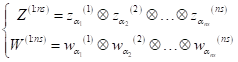                                                                                              

where the **univariate sampling of each stochastic variable** is defined by the $n_j$ abscissas $z_{\alpha_j}^{(j)} = \left\{z_k^{(j)}\right\}_{k=1}^{n_j}$ and the corresponding weights $w_{\alpha_j}^{(j)} = \left\{w_k^{(j)}\right\}_{k=1}^{n_j}$, for $j = 1, 2, \ldots, ns$.

In practice, the multivariate Gauss–Patterson rule is built by combining:

1.	the **one-dimensional rules** computed with gauss_patterson_nested_rule_1d, and
2.	the **multi-index** generated by get_seq.

Due to **nestedness**, many **tensor-product points** are **shared across levels** and can be reused efficiently.

The **supporting function gauss_patterson_nested_rule_nd (Fig. 4)** is designed to build such multivariate abscissas and weights.

***<font color='green'>@user Check the function below and run the cell to upload it in the notebook</font>***

In [ ]:
def gauss_patterson_nested_rule_nd(alphai, a, b, option):
    
    """
    :param alphai: multi-index of polynomial degrees
    :param a: lower bounds of uniform distributions
    :param b: upper bounds of uniform distributions
    :param option: 0 = standard GP, 1 = delayed nesting
    :return: (Z, W) with quadrature points and weights
    """

    # Initialization of the matrices
    nmodes = alphai.shape[0]
    z = [None] * nmodes
    w = [None] * nmodes

    # Precompute delayed multivariate Gauss-Patterson rule for maximum degree = 100 
    max_degree = 100
    alpha_nest_delayed = np.ones(max_degree + 1, dtype=int)
    for ll in range(2, max_degree + 1):
        p = 5
        o = 3
        while p < 2 * (ll - 1) + 1:
            p = 2 * p + 1
            o = 2 * o + 1
        alpha_nest_delayed[ll] = o

    # Generate 1D quadrature rules
    for n in range(nmodes):
        # For a given alpha_nest depending on the degree alpha of a given stochastic variable 
        # find the points and the weights of the univariate Gauss-Patterson quadrature.
        #
        # 1 - calculate alpha_nest
        level = alphai[n] + 1
        # accurate method
        if option == 0:
            alpha_nest = 2**level - 1
        # delayed method 
        else:
            alpha_nest = alpha_nest_delayed[level]
        # 2 - calculate Gauss-Patterson sequences: point z and weight w
        z[n], w[n] = gauss_patterson_nested_rule_1d(alpha_nest, a[n], b[n])

    # For all the stochastic variables, build the tensor grids of points z and weights w
    Z, W = np.array(z[0])[:, np.newaxis], np.array(w[0])
    for n in range(1,nmodes):
        Z = np.hstack([
            np.kron(Z, np.ones((len(z[n]), 1))),
            np.kron(np.ones((Z.shape[0], 1)), z[n][:, np.newaxis])
        ])
        W = np.kron(W, w[n])

    return Z, W

The INPUT parameters of the function are:

- integer **alphai[ns]** **multi-index** of polynomial degrees generated with get_seq 
- integer **a[ns], b[ns]** **limits of the uniform distributions**  
- integer **option** **0 = normal or 1 = delayed** Gauss-Patterson nested grid rules

The OUTPUT results of the function are:

- real **Z[ns,nwj]** **quadrature points/sampling** of the multivariate stochastic variables used to create the deterministic coefficients of the multivariate polynomial basis => **nwj** dimension of the samples **not known** before running the function
- real **W[nwj]** **weights** of the multivariate polynomial basis

***<font color='green'>@user Test the gauss_patterson_nested_rule function to understand how the multivariate rule is created & Test the impact of using the normal or delayed options on the size of the outputs</font>***

In [ ]:
"""
Testing the gauss_patterson_nested_rule function
In particular find the result for the GP and DGP rules with a total order p = 5 and 3 stochastic variables uniformly distributed and defined on the intervals [5 10], [-1 3] and [150 1300] 
""" 
#**************************
# Fill missing values below
#**************************
ns =
p  =
alpha_norm =
a = 
b = 
option = 
#------------
# Multi-index
#------------
alpha = get_seq(ns,alpha_norm)
print("alpha = ",alpha)
nnn=alpha.shape
#--------------------------------------------------
# Multivariate Sampling of the Interval and Weights
#--------------------------------------------------
for i in range(nnn[0]):
    alphai = alpha[i,:]
    print("alphai = ",alphai)
    Z,W = gauss_patterson_nested_rule_nd(alphai,a,b,option)
    print("Z = ", Z)
    print("W = ", W)


### 3) GENERATION OF THE USER INPUT

Based on the chosen stochastic variables, mathematical framework and sampling functions presented in the previous sections, the **first task of the user** is to tune the **python program Volcano_Meteo_Tsurrogate_step1_user_input** for their own applications.

For the **test cases** used in this notebook, the **user** should **NOT MODIFY** the number and locations of the volcanoes, nor the synthetic atmospheric disturbance formulation nor the distributions of the stochastic variables **presented in the previous sections**. 

**The user should also follow the instructions below:**

- the stochastic variables should be listed in this order using the SI units: **Lamb wave pressure at the epicenter of the volcanic eruption [Pa], Lamb wave wavelength [m], Lamb wave propagation speed [m/s] and Lamb wave time attenuation [s]**;
- the volcanoes locations should be listed in this order: **Askja, Campi Flegrei, Cotopaxi, Hunga Tonga-Hunga Ha'apai, Katla, Mt. Pinatubo, Popocatepetl, Mt. St. Helens, Mt. Sakurajima, Vesuvius, Yellowstone**;
- the maximum total order should be prescribed to $p=6$
- the **delayed Gauss-Patterson rule** should be used.

***<font color='green'>@user Complete the "Volcano_Meteo_Tsurrogate_step_1_user_input" code below and, then Run the cell below in order to create the variables used for the 11 studied volcanoes</font>***

In [ ]:
"""
-----------------------------
Volcano-Meteo-Tsurrogate v1.0
-----------------------------

contact: Clea Denamiel
email: clea.denamiel@live.fr

-----------------------------
STEP 1: user-defined criteria 
-----------------------------

!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Before performing this step:
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Edit Volcano_Meteo_Tsurrogate_step_1_user_input to define:
                                   - the stochastic vaiables: type, number and limits of the uniform distributions
                                   - the volcanoes: number and coordinates
                                   - the maximum total order
                                   - the quadrature rule: Gauss-Patterson (GP) or Delayed Gauss-Patterson (DGP)
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
"""

"""
USER SPECIFICATIONS
"""
#---------------------------------------------------------------------------------------------
# In this section the user defines the number of stochastic variables and their distributions.
# In version v1.0, all the distributions are ussumed to be uniform. 
#----------------------------------------------------------------------------------------------

print('Complete the program.')
### --------------------------------------------------------------- 
### USER ACTION
### Find the information in the User Manual and complete the values
### --------------------------------------------------------------- 

# Number of stochastic variables used to build the surrogate models
nmodes = 	

# Limits [a,b] of the stochastic variable uniform distributions
a=np.zeros(nmodes)
b=np.zeros(nmodes)
# stochastic variable 00 uniform distribution limits
a[0] =
b[0] =
# ...

# Number of volcanoes to simulate
nvols = 

# Coordinates of the Volcano locations
lon=np.zeros(nvols)
lat=np.zeros(nvols)
# volcano 00 coordinates
lon[0] =
lat[0] =
# ...

# Maximum total order of the Legendre polynomials that will be tested
maxdeg =

# type of nested grid option = 0 for Gauss-Patterson (GP) & option = 1 for Delayed Gauss-Patterson (DGP)
option =

"""
END USER SPECIFICATIONS
"""

# save as mat file in order to be used later for the construction, convergence, evaluation, sensitivity of the surrogate models
sio.savemat('results/output_users.mat', {'nmodes': nmodes,'a': a,'b': b,'nvols': nvols,'lon': lon,'lat': lat,'maxdeg': maxdeg,'option': option})

print(" ")
print("The results have been saved in: results/output_users.mat")
print(" ")


The **first step** of generating **surrogate models** based on gPCE is now **completed**.

***<font color='green'>@user Have a look at the new file in the results folder</font>***

--------------------------------------------------
## STEP 2: PARAMETERS FOR THE DETERMINISTIC SIMULATIONS
--------------------------------------------------

### 1) SPARSE GRID CONSTRUCTION

In **Volcano-Meteo-Tsurrogate v1.0**, the **Smolyak sparse-grid construction** combined with the non-intrusive **Pseudo-Spectral Approximation (PSA)** method is used to **rapidly decrease the error** in the compuation of the quadrature rule as the **number of deterministic simulations needed increases**. 

This approach is particularly **well suited** for **uncertainty quantification** problems involving **multiple stochastic variables**.

The theoretical background and numerical implementation of the approach follow the methodology described in:

- Florian Heiss, Viktor Winschel (2008): "Likelihood approximation by numerical integration on sparse grids".Journal of Econometrics, Vol. 144, pp. 62-80.

The **building-block function surrogate_model_gauss_patterson_param (Fig. 4)** defines the stochastic parameter space based on the Smolyak sparse-grid construction combined with the Pseudo-Spectral Approximation (PSA) method to generate the **final ensemble of parameter combinations** required to run the **deterministic volcano–meteotsunami simulations**.

***<font color='green'>@user Check the function below and run the cell to upload it in the notebook</font>***

In [ ]:
def surrogate_model_gauss_patterson_param(maxdeg, nmodes, a, b, option):
    """
    :param maxdeg: maximum total order (int)
    :param nmodes: number of stochastic variables (int)
    :param a: lower bounds (array-like)
    :param b: upper bounds (array-like)
    :param option: 0 = normal GP, 1 = delayed GP (int)
    :return: list of dicts with Z arrays for each total degree between 0 & maxdeg
    """
    
    # Start computation of parameters for gPCE using Gauss-Patterson quadrature rule and the PSA
    param = [] 
    for nmaxdeg in range(maxdeg + 1):
        print(f"maxdeg = {nmaxdeg}")
        Z = []
        for alpha_norm1 in range(max(0, nmaxdeg - nmodes + 1), nmaxdeg + 1):
            # multi-index for alpha_norm1 using Smolyak algorithm
            alpha_set = get_seq(nmodes, nmodes + alpha_norm1)
            print(f"||alpha||_1 = {alpha_norm1}")
            # inner loop collecting product rules
            for idx, alpha in enumerate(alpha_set):
                print(f"Completion: {100 * (idx + 1) / len(alpha_set):.1f}%")
                Znew, _ = gauss_patterson_nested_rule_nd(alpha, a, b, option)
                Z.append(Znew)
        # Sort the nodes and merge repeated values (due to nested grids)
        if Z:
            Z = np.vstack(Z)
            Z = np.unique(Z.astype(np.float32), axis=0)
            Z = Z[np.lexsort(Z.T[::-1])]  # Sort by all columns
        else:
            Z = np.zeros((1, nmodes), dtype=np.float32)
        # store the final values 
        param.append({'Z': Z})

    return param

The INPUT parameters of the function are:

- integer **maxdeg** **total order** of the Legendre polynomials
- integer **nmodes** **number of stochastic variables**
- real **a[nmodes], b[nmodes]** **interval of definition** of the distributions [a,b]
  
The OUTPUT result of the function is:

- structure **param[maxdeg+1]** containing **Z[nmodes,nwj]** the chosen **samples of the stochastic variables** => nwj is the dimension of the set of samples


### 2) GENERATION OF THE PARAMETERS

**No user input is required for this step**.

All parameters needed to run the deterministic volcano–meteotsunami simulations are **defined automatically based on the choices made in Step 1**. 

The **user-oriented program** Volcano_Meteo_Tsurrogate_step2_input_parameters (Fig. 4) **generates and manages** the parameters internally, ensuring **consistency** with the selected stochastic variables, sampling strategy, and polynomial order. 

The program follows **5 steps**: 

(1) **downloading the input variables** from the file output_users.mat,

(2) **generating the parameters** with surrogate_model_gauss_patterson_param,

(3) **saving the parameters with volcano locations** in ascii files (one per volcano) serving as input to the deterministic simulations,

(4) **matching**, for each level from 0 to maxdeg,  **each set of parameters with the indices of the simulations** and saving results in index[nwj] in the param structure,

(5) **saving the param structure** in output_param.mat.

***<font color='green'>@user Modify the code "Volcano_Meteo_Tsurrogate_step_2_input_parameters" to include all the volcanoes of the test cases, then Run the cell below to create the parameters for the deterministic simulations</font>***

In [ ]:
""""
-----------------------------
Volcano-Meteo-Tsurrogate v1.0
-----------------------------

contact: Clea Denamiel
email: clea.denamiel@live.fr

----------------------------------------------------------------------------
STEP 2: generation of the input parameters for the deterministic simulations
----------------------------------------------------------------------------

!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Before performing this step:
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
STEP 1: Edit and run Volcano_Meteo_Tsurrogate_step_1_user_input to generate the file: results/output_users.mat
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
"""

# Load the user-defined input
users = pth('results/output_users.mat')
if users.is_file():
	nmodes = sio.loadmat(users)['nmodes'].flatten()
	a = np.squeeze(np.array(sio.loadmat(users)['a']))
	b = np.squeeze(np.array(sio.loadmat(users)['b']))
	nvols = sio.loadmat(users)['nvols'].flatten()
	lon = np.squeeze(np.array(sio.loadmat(users)['lon']))
	lat = np.squeeze(np.array(sio.loadmat(users)['lat']))
	maxdeg = sio.loadmat(users)['maxdeg'].flatten()
	option = sio.loadmat(users)['option'].flatten()
else:
	print("The file: ",users," does not exist.")
	print("Edit and run Volcano_Meteo_Tsurrogate_step_1_user_input.")
		
# Generate the parameters P0, c, lambda, tau identical for the chosen volcanoes
param = surrogate_model_gauss_patterson_param(maxdeg[0], nmodes[0], a, b, option[0])
sim_atlas = np.array(param[maxdeg[0]]['Z'])
nnn=sim_atlas.shape
print(" ")
print("The total number of deterministic simulations to run is: ",nnn[0])
print(" ")

# For the Askja volcano, save parameters (lon, lat, P0, c, lambda, tau) in ascii file to be used as input of the deterministic simulations
## Askja
lon_col = np.full((nnn[0],1),lon[0])
lat_col = np.full((nnn[0],1),lat[0])
final_matrix = np.hstack((lon_col,lat_col,sim_atlas))
np.savetxt(f"results/volcano_00_params_order_6.txt", final_matrix,fmt="%.6f",delimiter=" ")
    
print("The ascii file has been saved in: results/volcano_00_params_order_6.txt")
print(" ")

print('Complete the program to include all volcanoes')
### --------------------------------
### USER ACTION
### Complete for the other volcanoes
### -------------------------------- 

# Match the indices of the simulations at maximum order order with lower orders (nested grids)
for i in range(maxdeg[0]+1):
	sim = np.array(param[i]['Z'])
	_, idx_sim, idx_atlas = np.intersect1d(sim.view([('', sim.dtype)]*sim.shape[1]),sim_atlas.view([('', sim_atlas.dtype)]*sim_atlas.shape[1]),return_indices=True)
	ind = idx_atlas
	param[i]['index'] = ind.flatten()
		
# Save param as mat file to be used for the construction, convergence, evaluation, sensitivity of the surrogate models
sio.savemat('results/output_param.mat', {'param': param})
	
print("The results have been saved in: results/output_param.mat")
print(" ")

The **second step** of generating surrogate models based on gPCE is now **completed**.

***<font color='green'>@user Have a look at the new files in the results folder</font>***

### 3) VISUALIZATION

A basic **visualization** of the volcano **locations**, as well as the **sparse grids**, can now be generated.

***<font color='green'>@user Complete the code, then Run the cell below to generate some plots</font>***

In [ ]:
"""
Visualization of the volcano locations and the sparse grids
"""
## Define nvols
### Example for Askja
nvols = 1

print('Complete the program to include all volcanoes')
### --------------------------------------------------------------- 
### USER ACTION
### load nvols from results/output_users.mat to update the nvols
### --------------------------------------------------------------- 

## Define name of the volcanoes
### Example for Askja
volcano_names = ["Askja"]

print('Complete the program to include all volcanoes')
### ------------------------- 
### USER ACTION
### Define for all volcanoes
### -------------------------

## Load lon, lat, P0, c, lambda, tau from ascii files 
### Example for Katla
vol = np.loadtxt(f'results/volcano_00_params_order_6.txt')
lon, lat, P0, lbda, c, tau = vol[0, 0], vol[0, 1], vol[:, 2], vol[:, 3], vol[:,4], vol[:,5]

print('Complete the program to include all volcanoes')
### --------------------------------------------------------------- 
### USER ACTION
### Define for all volcanoes 
### hint: 
### appart for the locations, all other parameters are the same 
### for all volcanoes
### --------------------------------------------------------------- 

"""
Geographical locations of the volcanoes
"""
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.Robinson())
# Plot Volcano locations
pts_P, = ax.plot(lon, lat, 'ro',transform=ccrs.PlateCarree())
cursor = mplcursors.cursor(pts_P, hover=True)
ax.coastlines(resolution='110m')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.LAND, facecolor='khaki')
ax.set_global()
ax.grid(True)
#fig.tight_layout()
plt.title("Check volcano locations on the map")
plt.show()

@cursor.connect("add")
def on_add(sel):
    i = sel.index
    sel.annotation.set_text(volcano_names[i])

"""
Sparse grids
"""
# HINT: Use Askja volcano only as all volcanoes have same stochastic variable distributions 

## 2D sparse grids
###  Example: 2D scatter plot of sparse grid between P0 & tau
fig = go.Figure(go.Scatter(
    x=P0/100.0,
    y=tau/3600.0,
    mode='markers',
    marker=dict(color='red'),
    hovertemplate='Pressure amplitude (P0): %{x}<br>Time attenuation (tau): %{y}<extra></extra>'
))
fig.update_layout(
    title="2D Sparse Grid",
    xaxis_title="Pressure amplitude [hPa]",
    yaxis_title="Time attenuation [hours]"
)
fig.show()

print('Complete the program to include all volcanoes')
### --------------------------------------------------------------- 
### USER ACTION
### Create the 2D sparse grids for other combinations of parameters
### --------------------------------------------------------------- 

## 3D sparse grids
### Example: 3D scatter plot of sparse grid between P0, tau & c
fig = go.Figure(go.Scatter3d(
    x=P0/100.0,
    y=tau/3600.0,
    z=c,
    mode='markers',
    marker=dict(color='red', size=5),
    hovertemplate='Pressure amplitude (P0): %{x}<br>Time attenuation (tau): %{y}<br>Propagation speed (c): %{z}<extra></extra>'
))
fig.update_layout(
    width=1000,
    height=1000,
    title='3D Sparse Grid',
    scene=dict(
        xaxis_title='Pressure amplitude [hPa]',
        yaxis_title='Time attenuation [hours]',
        zaxis_title='Propagation speed [m/s]'
    )
)
fig.show()

print('Complete the program to include all volcanoes')
### --------------------------------------------------------------- 
### USER ACTION
### Create the 3D sparse grids for other combinations of parameters
### --------------------------------------------------------------- 

--------------------------------------------------
## STEP 3: DETERMINISTIC SIMULATION RUNS
--------------------------------------------------

This step **cannot be completed** through the **Jupyter Notebook** in this **User Manual**, as running the deterministic simulations requires significant numerical resources.

As the global simulation **output are large**, the result of the numerical simulations for the test cases are only provided for **191 selected worldwide coastal locations** corresponding to: 

-	**86 long-term tide-gauge locations of the IOC network** enabling direct comparison of surrogate model results with observations and thereby contributing to the continuous evaluation and validation of the surrogate approach,
-	**105 populated and/or endangered coastal cities as identified by Barragán and de Andrés (2015)**—e.g., Barcelona (Spain), Copenhagen (Denmark), Edinburg (Scotland), Helsinki (Finland), Lisbon (Portugal), Nice (France), Venice (Italy), Auckland (New Zealand), Perth and Sydney (Australia), Bangkok (Thailand), Hong Kong (China), Honolulu (Hawaii), Tokyo (Japan), Cape Town (South Africa), Dubai (United Arab Emirates), Istanbul (Türkiye), Jakarta (Indonesia), Los Angeles and New York City (USA) and Rio de Janeiro (Brazil).

The results are stored in the **netcdf file data/input_simus.nc** with the following structure:

**netcdf input_simus {**

dimensions:

        volc = 11 ;		% number of volcanoes
        city = 191 ;	% number of coastal locations
        simu = 641 ;	% number of simulations 

variables:

        double zeta_max(volc, city, simu) ;
                zeta_max:units = "m" ;
                zeta_max:long_name = "meteotsunami surge" ;
                zeta_max:_FillValue = 9.96920996838687e+36 ;
        double time_zeta_max(volc, city, simu) ;
                time_zeta_max:units = "hours" ;
                time_zeta_max:long_name = "time of arrival of the meteotsunami surge" ;
                time_zeta_max:_FillValue = 9.96920996838687e+36 ;
        double vel_max(volc, city, simu) ;
                vel_max:units = "m/s" ;
                vel_max:long_name = "meteotsunami maximum speed" ;
                vel_max:_FillValue = 9.96920996838687e+36 ;
**}**

The coordinates (latitude and longitude) and the names of the coastal locations are stored in the **matlab-like file data/surrogate_model_locations.mat** containing the variables:

-	loc_lon        [191 x1 double]
-	loc_lat         [191 x 1 double]
-	loc_name   {191 x 1 cell}

**Important Note**: The gPCE decomposition requires the **tsunami hazard quantities** to have **continuous distributions**—i.e., **NaN values are not allowed**. This implies that the selected **locations** must be sufficiently deep to remain submerged (**outside the inundation zone**), ensuring that the maximum elevation, maximum speed, and time of arrival are **defined for all deterministic simulations**.

------------------------------------------------------
## STEP 4: SIMULATION OUTPUT FORMATTING
------------------------------------------------------

In this step, it is assumed that the **outputs of the deterministic simulations**, and the **locations** where the surrogate models are to be built, have already been stored in **files decribed in Step 3**. The  **surrogate_model_locations.mat** file is already **provided in the data folder** but, due to its size, the **input_simus.nc must be downloaded**.

***<font color='green'>@user Run the cell to download the simulation results.</font>***

In [ ]:
url = 'https://drive.google.com/file/d/19oAWVE9gREZxL_0gu8YIhL6dMLfoRpYU/view?usp=sharing'
output = 'data/input_simus.nc'
gdown.download(url, output, quiet=False, fuzzy=True)

***<font color='green'>@user Modify the code "Volcano_Meteo_Tsurrogate_step_4_format_simulations" to include all the volcanoes of the test cases, then Run the cell below to format the outputs of the deterministic simulations for the 191 coastal locations and the 11 volcanoes of the test cases</font>***

In [ ]:
""""
-----------------------------
Volcano-Meteo-Tsurrogate v1.0
-----------------------------

contact: Clea Denamiel
email: clea.denamiel@live.fr

Look at the User Manual for more information.

----------------------------------------------------------
STEP 4: format the user-provided deterministic simulations
----------------------------------------------------------


!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Before performing this step:
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
STEP 1: Edit and run Volcano_Meteo_Tsurrogate_step_1_user_input to generate the file: results/output_users.mat
STEP 2: Run Volcano_Meteo_Tsurrogate_step_2_input_parameters to generate the file: results/output_param.mat
STEP 3: Run the deterministic simulations outside Volcano-Meteo-Tsurrogate v1.0 and generate: data/input_simus.nc
        input_simus.nc:  contains the maximum elevation, the maximum speed and the time of arrival of the meteotsunamis.
        --------------- 
        netcdf input_simus {
        dimensions:
            volc = 11 ;     % number of volcanoes
            city = 191 ;	% number of coastal locations
            simu = 641 ;	% number of simulations 
        variables:')
            double zeta_max(volc, city, simu) ;
                zeta_max:units = "m" ;
                zeta_max:long_name = "meteotsunami surge" ;
                zeta_max:_FillValue = 9.96920996838687e+36 ;
            double time_zeta_max(volc, city, simu) ;
                time_zeta_max:units = "hours" ;
                time_zeta_max:long_name = "time of arrival of the meteotsunami surge" ;
                time_zeta_max:_FillValue = 9.96920996838687e+36 ;
            double vel_max(volc, city, simu) ;
                vel_max:units = "m/s" ;
                vel_max:long_name = "meteotsunami maximum speed" ;
                vel_max:_FillValue = 9.96920996838687e+36 ;
        }

        Provide the locations where to the surrogates are created and generate: ../data/surrogate_model_locations.mat
        surrogate_model_locations.mat: contains loc_lon[nl x 1 double], loc_lat[nl x 1 double] and loc_name{nl x 1 cell},
        ------------------------------  longitude, latitude and name of the locations and nl the number of locations        
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
If the program and data are not edited this program formats the results from the 11 volcanoes of the test cases as
described in the User Manual.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
"""		
#-------------------------
# Load general information
#-------------------------
# Read the user-defined input in output_users.mat
users = pth('results/output_users.mat')
if users.is_file():
    print('Complete the program to include all volcanoes')
    ### ------------------------------------------ 
    ### USER ACTION
    ### read nvols needed to work on all volcanoes
    ### ------------------------------------------
else:
    print("The file: ",users," does not exist.")
    print("Edit and run Volcano_Meteo_Tsurrogate_step_1_user_input.")

# Read output_param.mat created by Volcano_Meteo_Tsurrogate_step_2_input_parameters
my_file = pth('results/output_param.mat')
if my_file.is_file():
   param_data = sio.loadmat(my_file)
   param = np.squeeze(np.array(param_data['param']))
   maxdeg=len(param.flatten())-1
   nsim=len(param[maxdeg]['index'][0][0].flatten())
else:
   print("The file: ",my_file," does not exist.")
   print("Run Volcano_Meteo_Tsurrogate_step_2_input_param.")
	
# Read the user provided file: surrogate_model_locations.mat, containing loc_lon, loc_lat and loc_name    
my_file = pth('data/surrogate_model_locations.mat')
if my_file.is_file():
          data = sio.loadmat(my_file)
          loc_lon = data['loc_lon'].flatten()
          loc_lat = data['loc_lat'].flatten()
          loc_name = data['loc_name'].flatten()
else:
   print("The file: ",my_file," does not exist.")
   print("Produce this file as instructed above.")

# Read the user provided file: input_simus.nc, containing the results of the deterministic simulations
my_file = pth('data/input_simus.nc')
if my_file.is_file():
          ds = xr.open_dataset(my_file, decode_timedelta=False)
          zeta_max = ds['zeta_max'].values
          time_zeta_max = ds['time_zeta_max'].values
          velo_max = ds['vel_max'].values
else:
   print("The file: ",my_file," does not exist.")
   print("Produce this file as instructed above.")
	   
#-------------------------
# Reformat the simulations
#-------------------------
### For Askja only
# Initialize the model list
model = np.empty((1, nsim), dtype=object)
# Loop through each simulation and extract data
for i in range(nsim):
    model[0, i] = {
         'Zeta_Z': zeta_max[0, :, i], 
		 'Velo_Z': velo_max[0, :, i],
		 'Time_Zeta_Z': time_zeta_max[0, :, i]
	}
    
### -------------------------------- 
### USER ACTION
### Complete for the other volcanoes 
### -------------------------------- 

# Save the model to a .mat file
sio.savemat('results/output_model.mat', {'model': model})

print(" ")
print("The results have been saved in: results/output_model.mat")
print(" ")

**Important Note**: Users are **free to modify the format of the input files** (input_simus.nc and surrogate_model_locations.mat) as well as the **corresponding reading procedures** in the program Volcano_Meteo_Tsurrogate_step_4_format_simulations **BUT** the format of the output_model.mat file **must be kept** for an **optimal use of the software**.


The **fourth step** of generating surrogate models based on gPCE is now **completed**.

***<font color='green'>@user Have a look at the new files in the results folder</font>***

------------------------------------------------------
## STEP 5: COEFFICIENTS OF THE gPCE
------------------------------------------------------
### 1) QUADRATURE FUNCTIONS 

In this step the **coefficients** $C_{|\alpha|,\beta}$ of the **gPCE decomposition** $\xi_{max,p}$ at the total order $p$ are computed. The approach approximates the projection of the **meteotsunami hazard quantities**—$\xi_{max}$, maximum elevation, maximum speed and time of arrival based on the **deterministic volcano–meteotsunami simulations** $\xi_{max}(Z^{(1:ns)})$—into the **Legendre polynomial basis** $\Psi_{\beta}$ with the **quadrature rule** $Q^{(1:ns)}(\xi_{max} \Psi_{\beta})$. 

For each $\alpha$ from $max(0,p-ns+1) \leq |\alpha| \leq p$, the multi-index $\pmb{\beta}=[\pmb{\beta_1},\pmb{\beta_2},\ldots,\pmb{\beta_{ns}}]$ stores all the polynomial combinations needed to calculate the **gPCE decompostion** as follows [Eq.(4)]:

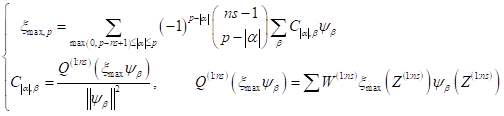

The **two functions** below are used to calculate the **deterministic coefficients** of the gPCE. The functions **assume** that all the stochastic variables follow **uniform distributions** and employ the **Legendre polynomials**. 

The **first function** provides the **squared L2 norm** of a specified **Legendre polynomial** over a given interval [a,b].

***<font color='green'>@user Check the function below and run the cell to upload it in the notebook</font>***

In [ ]:
def norm2_legendre_polynomials(degree, a, b):
    """
    Parameters:
    - degree: int, the degree of the Legendre polynomial.
    - a: float, lower bound of the interval.
    - b: float, upper bound of the interval.
    Returns:
    - PsiN2: float, the squared L2 norm of the Legendre polynomial over [a, b].
    """

    # Initialize list to store polynomial coefficients
    Le = [None] * (degree + 1)
    Le[0] = np.array([1.0])       # L_0(x) = 1
    if degree >= 1:
        Le[1] = np.array([1.0, 0.0])   # L_1(x) = x
    # Generate Legendre polynomials using recurrence relation
    for n in range(2, degree + 1):
        coeff1 = ((2 * n - 1) / n) * np.concatenate((Le[n - 1], [0]))
        coeff2 = ((n - 1) / n) * np.concatenate(([0, 0], Le[n - 2]))
        Le[n] = coeff1 - coeff2
    # Define the function to integrate
    def integrand(x):
        # Map x from [a, b] to [-1, 1]
        x_mapped = (2 * x - a - b) / (b - a)
        # Evaluate the polynomial at x_mapped
        poly_val = np.polyval(Le[degree], x_mapped)
        return poly_val ** 2
    # Perform numerical integration over [a, b]
    PsiN2, _ = quad(integrand, a, b)
    return PsiN2

The INPUT parameters of the function are:

- integer **degree** Legendre polynomial **degree**
- real **a,b** interval of definition [a,b] with b > a
        
The OUTPUT result of the function is:

- real **PsiN2** **squared L2 norm** of the Legendre polynomial at the defined degree over the [a,b] interval of definition
    
***<font color='green'>@user Test the norm2_legendre_polynomials function to understand how it works</font>***

In [ ]:
"""
Test the norm2_legendre_polynomials function
"""
degree = 
a = 
b = 
norm_squared = norm2_legendre_polynomials(degree, a, b)
print(f"Squared L2 norm: {norm_squared}")

The **second function** calculates the **deterministic coefficients of the gPCE** using the **PSA** with the **Gauss-Patterson** sparse grids and is based on the following litterature:

- Florian Heiss, Viktor Winschel (2008): "Likelihood approximation by numerical integration on sparse grids", Journal of Econometrics, Vol. 144, pp. 62-80.

**Important Note**: 

- Since **maximum elevation and maximum speed** are **strictly positive** and have a **large number of small values**, the **gPCE** are contructured for the **logarithm of these quantities**. This ensures that the **final results**—obtained by exponentiating the outputs—remain **positive**. This approach allows for a **better representation** of the **lower-end values** but may introduce some **distortion** in the **higer-end values**.
- However, for the **time of arrival**, a **large number of values are around 10 to 20 hours**, and the **logarithm transform** does **not improve the final results**. To minimize the creation of **negative final gPCE results**, the **time is treated in seconds** and the rarely occuring negative values are **ignored**.   

***<font color='green'>@user Check the function below and run the cell to upload it in the notebook</font>***

In [ ]:
def surrogate_model_gauss_patterson_coeff(param, model, a, b, maxdeg, option):
    
    """
    Parameters:
    - param: list of dictionaries containing 'Z' and 'index' keys.
    - model: list of dictionaries containing 'Zeta_Z', 'Velo_Z', and 'Time_Zeta_Z'.
    - a, b: arrays defining the limits of the uniform distribution.
    - maxdeg: maximum to tal order for the polynomial chaos expansion.
    - option: 0 for normal or 1 for delayed Gauss-Patterson sequences.
    Returns:
    - coeff: list of dictionaries containing 'alpha', 'zeta', 'velo', and 'time'.
    """
    # Initialization of the matrices
    nmodes = len(a)
    nx = len(model[0]['Zeta_Z'][0][0].flatten())
    # Generate Legendre Polynomials up to maxdeg
    Le = [None] * (maxdeg + 1)
    Le[0] = np.array([1.0])  # L_0 = 1
    Le[1] = np.array([1.0, 0.0])  # L_1 = x
    for n in range(2, maxdeg + 1):
        Le[n] = ((2 * n - 1) / n) * np.concatenate((Le[n - 1], [0])) - ((n - 1) / n) * np.concatenate(([0, 0], Le[n - 2]))
    # gPCE computation
    coeff = []
    Z = np.array(param[0][maxdeg]['Z'][0][0])
    index = param[0][maxdeg]['index'][0][0].flatten()
    for alpha_norm1 in range(maxdeg+1):        
        print('-------------------------------')
        print(f'||alpha||_1 = {alpha_norm1}')
        print('-------------------------------')
        # reset index to zero
        start = 0
        # multi-indexes alphal with sum equal to alpha_norm1
        alpha = get_seq(nmodes, nmodes + alpha_norm1)
        alpha_final = []
        zeta_final = []
        velo_final = []
        time_final = []
        for l in range(alpha.shape[0]):
            print(f'Completion: {100 * (l + 1) / alpha.shape[0]:.2f}%')            
            Znew, Wnew = gauss_patterson_nested_rule_nd(alpha[l, :], a, b, option)
            Znew = Znew.astype(np.float32)
            # find the corresponding simulations
            Zeta_Z = np.full((nx, len(Wnew)), np.nan)
            Velo_Z = np.full((nx, len(Wnew)), np.nan)
            Time_Z = np.full((nx, len(Wnew)), np.nan)
            for ss in range(len(Wnew)):
                matches = np.all(Z == Znew[ss, :], axis=1)
                if np.any(matches):
                    ind_new = np.where(matches)[0][0]
                    # Log of the quantities to make sure to obtain positive results 
                    Zeta_Z[:, ss] = np.log(model[index[ind_new]]['Zeta_Z'][0][0].flatten())
                    Velo_Z[:, ss] = np.log(model[index[ind_new]]['Velo_Z'][0][0].flatten())
                    # time treated in seconds and without log transform
                    Time_Z[:, ss] = (model[index[ind_new]]['Time_Zeta_Z'][0][0].flatten())*3600.0
            # multi-indexes alpha_sum varying between [0 0 ... 0] and alphal
            max_alpha = np.max(alpha[l, :])
            alpha_sum = np.array(np.meshgrid(*[np.arange(max_alpha + 1) for _ in range(nmodes)])).T.reshape(-1, nmodes)
            mask = np.all(alpha_sum <= alpha[l, :], axis=1)
            alpha_sum = alpha_sum[mask]
            zeta_temp = np.zeros((nx, alpha_sum.shape[0]))
            velo_temp = np.zeros((nx, alpha_sum.shape[0]))
            time_temp = np.zeros((nx, alpha_sum.shape[0]))
            for s in range(alpha_sum.shape[0]):
                # calculate the quadrature coefficients
                qrule_coeff = Wnew.copy()
                for n in range(nmodes):
                    x_scaled = (2 * Znew[:, n] - a[n] - b[n]) / (b[n] - a[n])
                    poly_val = np.polyval(Le[alpha_sum[s, n]], x_scaled)
                    norm = norm2_legendre_polynomials(alpha_sum[s, n], a[n], b[n])                    
                    qrule_coeff *= poly_val / norm
                # Quadrature rule - Coefficients of the gPCE
                zeta_temp[:, s] = Zeta_Z @ qrule_coeff
                velo_temp[:, s] = Velo_Z @ qrule_coeff
                time_temp[:, s] = Time_Z @ qrule_coeff
            # Store results for this degree
            alpha_final.append(alpha_sum)
            zeta_final.append(zeta_temp)
            velo_final.append(velo_temp)
            time_final.append(time_temp)
        # Store final results 
        coeff.append({
            'alpha': np.vstack(alpha_final),
            'zeta': np.hstack(zeta_final),
            'velo': np.hstack(velo_final),
            'time': np.hstack(time_final)
        })

    return coeff

The INPUT parameters of the function are:

- structure **param[maxdeg+1]** containing the paramters: Z[nmodes,nwj] the chosen samples of the stochastic variables and index[nwj] the index corresponding to the unique deterministic simulation 
- structure **model[nwj]** containing the formated deterministic outputs: **Zeta_Z[nx]**  the maximum elevation, **Velo_Z[nx]** the maximum speed and **Time_Z[nx]** the time of arrival of the tsunami waves at the **locations [nx]** where the surrogate models need to be built
- integer **maxdeg** maximum **total order** of the Legendre polynomials
- real **a[nmodes],b[nmodes]** interval of definition [a,b] with b > a
- integer **option** **0 = normal or 1 = delayed** Gauss-Patterson sequencies 
        
The OUTPUT result of the function is:
- structure **coeff[maxdeg+1]** containing the **multi-index alpha[nl,nmodes]** of **dimension [nl]** and the **coefficients of the gPCE zeta[nx,nl], velo[nx,nl] and time[nx,nl]** for respectively the maximum elevation, the maximum speed and the time of arrival at the **locations [nx]** where the surrogate models are built.

### 2) GENERATION OF THE gPCE COEFFICIENTS

***<font color='green'>@user Edit the program "Volcano_Meteo_Tsurrogate_step_5_coefficients" to include all volcanoes and then, Run the cell below to create the gPCE coefficients for the surrogate models</font>***

In [ ]:
"""
-----------------------------
Volcano-Meteo-Tsurrogate v1.0
-----------------------------

contact: Clea Denamiel
email: clea.denamiel@live.fr

Look at the User Manual for more information.

------------------------------------------------------------------------------
STEP 5: generation of the deterministic coefficients of the gPCE decomposition
------------------------------------------------------------------------------

!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Before performing this step:
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
STEP 1: Edit and run Volcano_Meteo_Tsurrogate_step_1_user_input to generate the file: results/output_users.mat
STEP 2: Run Volcano_Meteo_Tsurrogate_step_2_input_parameters to generate the file: results/output_param.mat
STEP 3: Run the deterministic simulations outside Volcano-Meteo-Tsurrogate v1.0 and generate: data/input_simus.nc
        input_simus.nc: contains the maximum elevation, the maximum speed and the time of arrival of the meteotsunamis.
        ---------------  
        netcdf input_simus {
        dimensions:
            volc = 11 ;     % number of volcanoes
            city = 191 ;	% number of coastal locations
            simu = 641 ;	% number of simulations
        variables:
            double zeta_max(volc, city, simu) ;
                zeta_max:units = "m" ;
                zeta_max:long_name = "meteotsunami surge" ;
                zeta_max:_FillValue = 9.96920996838687e+36 ;
            double time_zeta_max(volc, city, simu) ;
                time_zeta_max:units = "hours" ;
                time_zeta_max:long_name = "time of arrival of the meteotsunami surge" ;
                time_zeta_max:_FillValue = 9.96920996838687e+36 ;
            double vel_max(volc, city, simu) ;
                vel_max:units = "m/s" ;
                vel_max:long_name = "meteotsunami maximum speed" ;
                vel_max:_FillValue = 9.96920996838687e+36 ;
        }

        Provide the locations where to the surrogates are created and generate: data/surrogate_model_locations.mat
        surrogate_model_locations.mat: contains loc_lon[nl x 1 double], loc_lat[nl x 1 double] and loc_name{nl x 1 cell}, 
        ------------------------------  longitude, latitude and name of the locations and nl the number of locations
STEP 4: Run Volcano_Meteo_Tsurrogate_step_4_format_input to generate the file: results/output_model.mat
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
"""
#--------------
# Load the data
#--------------

# Load the user-defined input
users = pth('results/output_users.mat')
if users.is_file():
	nmodes = sio.loadmat(users)['nmodes'].flatten()
	a = np.squeeze(np.array(sio.loadmat(users)['a']))
	b = np.squeeze(np.array(sio.loadmat(users)['b']))
	maxdeg = sio.loadmat(users)['maxdeg'].flatten()
	option = sio.loadmat(users)['option'].flatten()
	nvols  = sio.loadmat(users)['nvols'].flatten()
else:
	print("The file: ",users," does not exist.")
	print("Edit and run Volcano_Meteo_Tsurrogate_step_1_user_input.")
# Load the parameters 
my_file = pth('results/output_param.mat')
if my_file.is_file():
   param = sio.loadmat(my_file)['param']
else:
   print("The file: ",my_file," does not exist.")
   print("Generate the file as instructed above.")
#Load the deterministic simulation output
my_file = pth('results/output_model.mat')
if my_file.is_file():	 
   model = sio.loadmat(my_file)['model']
else:
   print("The file: ",my_file," does not exist.")
   print("Generate the file as instructed above.")
   
#--------------------------
# Generate the coefficients
#--------------------------

# Askja only
coeff = np.empty((1, maxdeg[0]+1), dtype=object)
model_temp = model[0]
coeff_temp = surrogate_model_gauss_patterson_coeff(param,model_temp,a,b,maxdeg[0],option[0])
coeff[0] = coeff_temp

print('Complete the program to include all volcanoes')
### -------------------------------- 
### USER ACTION
### Complete for the other volcanoes 
### -------------------------------- 

sio.savemat('results/output_coeff.mat',{'coeff': coeff})

print(" ")
print("The results have been saved in: results/output_coeff.mat")
print(" ")

The **fifth step** of generating surrogate models based on gPCE decomposition is now **completed**.

***<font color='green'>@user Have a look at the new files in the results folder</font>***

------------------------------------------------------
## STEP 6: EVALUATION OF CONVERGENCE, PERFORMANCE AND SENSITIVITY
------------------------------------------------------
### 1) EVALUATION FUNCTIONS

The **evaluation of the Volcano-Meteo-Tsurrogate model**, for each meteotsunami hazard quantity, is performed in **three sub-steps**. 

**First**, the **convergence of the method** is verified depending on the total order   of the decomposition based on the normalized root-mean-square errors (NRMSE) $e_{p}$  calculated with the $N$ deterministic simulations $\xi_{\max} (Z^{(1:ns)}_N)$ and the corresponding surrogate model results $\xi_{\max,p} (Z^{(1:ns)}_N)$ [Eq. (5)]:

$e_{p} = \frac{ \sum\limits_{N} \left( \xi_{\max} (Z^{(1:ns)}_N) - \xi_{\max,p} (Z^{(1:ns)}_N) \right)^2 }{ \sum\limits_{N} \left( \xi_{\max} (Z^{(1:ns)}_N)- \xi_{\max,0} (Z^{(1:ns)}_N) \right)^2 }$
 
This sub-step allows to **find the order** $p_c$ at which the surrogate models **converge**—i.e. $\lim\limits_{p\to P_c} e_{p}=0$. 

**Second**, the **accuracy of the surrogate models** is evaluated by using the **additional deterministic simulations** created to **reach the level** $p_c + 1$. These simulations effectively sample the full range of the stochastic parameter space and can therefore serve a robust basis for accuracy assessment. 
 
***<font color='green'>@user Check the function below that stores the data for both convergence and performance and, then run the cell to upload it in the notebook</font>***

In [ ]:
def surrogate_model_gauss_patterson_evals(param, model, coeff, a, b, maxdeg):
    """
    Evaluation of Pseudo Spectral Approximation with Gauss-Patterson Sparse grids.
    """
    
    nmodes = len(a)
    nx = len(model[0][0]['Zeta_Z'][0][0].flatten())
    
    # Build Legendre polynomials up to maxdeg (Le[0] = constant 1, Le[1] = x, etc.)
    Le = [None] * (maxdeg + 1)
    Le[0] = np.array([1.0])  # L_0 = 1
    Le[1] = np.array([1.0, 0.0])  # L_1 = x
    for n in range(2, maxdeg + 1):
        Le[n] = ((2 * n - 1) / n) * np.concatenate((Le[n - 1], [0])) - ((n - 1) / n) * np.concatenate(([0, 0], Le[n - 2]))
    # Prepare error structure as a list of dicts
    evals = []
    # Retrieve all simulations  
    Z = np.array(param[0][maxdeg]['Z'][0][0])
    index = param[0][maxdeg]['index'][0][0].flatten()
    ns = Z.shape[0]
    Z = Z.T
    # Preallocate true-model matrices
    Zeta_Z = np.empty((nx, ns))
    Velo_Z = np.empty((nx, ns))
    Time_Z = np.empty((nx, ns))
    for i in range(ns):
        entry = model[index[i]]
        Zeta_Z[:, i] = np.array(entry['Zeta_Z'][0][0])
        Velo_Z[:, i] = np.array(entry['Velo_Z'][0][0])
        Time_Z[:, i] = np.array(entry['Time_Zeta_Z'][0][0])
    # Store the true values as error[0]
    evals.append({
        'Zeta_Z': Zeta_Z.copy(),
        'Velo_Z': Velo_Z.copy(),
        'Time_Z': Time_Z.copy()
    })
    # Loop over increasing maximal gPCE degree
    for nmaxdeg in range(0, maxdeg+1):    
        # initialize PCE approximations
        zeta_PCE = np.zeros((nx, ns))
        velo_PCE = np.zeros((nx, ns))
        time_PCE = np.zeros((nx, ns))        
        # Smolyak summation over alpha norms
        for alpha_norm1 in range(max(0, nmaxdeg - nmodes + 1), nmaxdeg + 1):
            # Smolyak coefficient
            C_alpha = ((-1)**(nmaxdeg - alpha_norm1) 
                       * comb(nmodes-1, nmaxdeg - alpha_norm1))            
            # Retrieve multi-indices and PCE coefficients for this alpha_norm1
            this = coeff[alpha_norm1]
            alpha_mat = np.array(this['alpha'][0][0]) 
            zeta_hat = np.array(this['zeta'][0][0])   
            velo_hat = np.array(this['velo'][0][0])
            time_hat = np.array(this['time'][0][0])
            nw = alpha_mat.shape[0]            
            # For each multi-index row
            for l in range(nw):
                alpha_row = alpha_mat[l]           
                # Build the product of univariate polynomials
                # multH: shape (ns,)
                multH = np.ones(ns)
                for m in range(nmodes):
                    x_scaled = (2 * Z[m, :] - a[m] - b[m]) / (b[m] - a[m])
                    P = np.polyval(Le[alpha_row[m]], x_scaled)
                    multH *= P                
                # Accumulate PCE contributions
                # Note: zeta_hat[:, l] is shape (nx,), so we outer with multH
                zeta_PCE += C_alpha * np.outer(zeta_hat[:, l], multH)
                velo_PCE += C_alpha * np.outer(velo_hat[:, l], multH)
                time_PCE += C_alpha * np.outer(time_hat[:, l], multH)      
        # make sure time values are positive
        time_PCE[time_PCE < 0.0] = np.nan
        print((np.isnan(time_PCE).sum()*100)/time_PCE.size,"% of negative time of arrival values were generated at total order p = ", alpha_norm1)
        # Exponentiate to undo the log transform and get the real values of the original quantities (except for time)
        evals.append({
            'Zeta_PCE': np.exp(zeta_PCE),
            'Velo_PCE': np.exp(velo_PCE),
            # convert time in hours
            'Time_PCE': time_PCE/3600.0
        })
    
    return evals

The INPUT parameters of the function are:

- structure **param[maxdeg+1]** containing the paramters: **Z[nmodes,nwj]** the chosen samples of the stochastic variables and **index[nwj]** the index corresponding to the unique deterministic simulations 
- structure **model[nwj]** containing the formated deterministic outputs: **Zeta_Z[nx]**  the maximum elevation, **Velo_Z[nx]** the maximum speed and **Time_Z[nx]** the time of arrival of the tsunami waves at the locations where the surrogate models need to be built
- structure **coeff[maxdeg+1]** containing the **multi-index alpha[nl,nmodes]** of **dimension [nl]** and the **coefficients of the gPCE zeta[nx,nl], velo[nx,nl] and time[nx,nl]** for respectively the maximum elevation, the maximum speed and the time of arrival at the **locations [nx]** where the surrogate models are built
- real **a[nmodes],b[nmodes]** interval of definition [a,b] with b > a
- integer **maxdeg** maximum **total order** of the Legendre polynomials

The OUTPUT result of the function is:
- structure **evals[maxdeg+2]** containing (1) **evals[0].Zeta_Z[nwj,nx], evals[0].Velo_Z[nwj,nx] and evals[0].Time_Z[nwj,nx]** the results of the deterministic simulations & (2) **avals[1:maxdeg+1].Zeta_PCE[nwj,nx], evals[1:maxdeg+1].Velo_PCE[nwj,nx], evals[1:maxdeg+1].Time_PCE[nwj,nx]** for the number of **deterministic simulations [nwj]**, and, at the **locations [nx]** where, the surrogate models are built

**Finally**, the **total sensitivity of the surrogate models** to the stochastic variables is derived from the coefficients of the gPCE decomposition (Crestaux, 2009) that provide the **Sobol’ indices** of the variance decomposition (**ANOVA**). The total Sobol’ indices quantify the relative contribution (ranging from 0 to >1) of each stochastic variable to the variability of meteotsunami hazard predictions at the selected locations. 

**Total sensitivity interpretation**:

- If a total sensitivity is below 0.01, the corresponding stochastic variable may be fixed to a deterministic value without significantly affecting hazard estimates.
- Total Sobol’ indices include both direct effects and interactions. Therefore, the sum of total indices may exceed 1. This is normal and does not indicate an error.

***<font color='green'>@user Check the function below that stores the data for sensitivity and, then run the cell to upload it in the notebook</font>***


In [ ]:
def surrogate_model_gauss_patterson_sensi(coeff, maxdeg):
    
    # Dimensions
    alpha0 = np.array(coeff[0]['alpha'][0][0])
    nx = np.array(coeff[0]['zeta'][0][0]).shape[0]
    nmodes = alpha0.shape[1]
    # Preallocate total sensitivity arrays
    sensi = []
    ST_Zeta = np.full((nx, nmodes), np.nan)
    ST_Velo = np.full((nx, nmodes), np.nan)
    ST_Time = np.full((nx, nmodes), np.nan)        
    # Gather all alpha and weighted coefficients
    alpha_list = []
    coeff_zeta = []
    coeff_velo = []
    coeff_time = []
    for alpha_norm1 in range(max(0, maxdeg - nmodes + 1), maxdeg + 1):
        # Smolyak coefficient
        C_alpha = ((-1) ** (maxdeg - alpha_norm1)
                   * comb(nmodes - 1, maxdeg - alpha_norm1))        
        entry = coeff[alpha_norm1]
        alpha_list.append(entry['alpha'][0][0])         
        coeff_zeta.append(C_alpha * entry['zeta'][0][0])
        coeff_velo.append(C_alpha * entry['velo'][0][0])
        coeff_time.append(C_alpha * entry['time'][0][0])
    # Concatenate along the coefficient index dimension
    alpha = np.vstack(alpha_list) 
    coeff_zeta = np.hstack(coeff_zeta)
    coeff_velo = np.hstack(coeff_velo)
    coeff_time = np.hstack(coeff_time)
    # Remove purely constant terms (all zeros in alpha row)
    non_constant = ~(np.sum(alpha == 0, axis=1) == nmodes)
    alpha_nc = alpha[non_constant, :]
    zeta_nc = coeff_zeta[:, non_constant]
    velo_nc = coeff_velo[:, non_constant]
    time_nc = coeff_time[:, non_constant]
    # Total variances
    D_zeta = np.sum(zeta_nc ** 2, axis=1)
    D_velo = np.sum(velo_nc ** 2, axis=1)
    D_time = np.sum(time_nc ** 2, axis=1)
    # Compute total Sobol's indices
    for i in range(nmodes):
        # indices of terms where alpha_nc[:, i] > 0
        indT = np.where(alpha_nc[:, i] > 0)[0]
        ST_Zeta[:, i] = np.sum(zeta_nc[:, indT] ** 2, axis=1) / D_zeta
        ST_Velo[:, i] = np.sum(velo_nc[:, indT] ** 2, axis=1) / D_velo
        ST_Time[:, i] = np.sum(time_nc[:, indT] ** 2, axis=1) / D_time
    # Store final results
    sensi.append({'ST_Zeta': ST_Zeta.copy(),
                        'ST_Velo': ST_Velo.copy(),
                        'ST_Time': ST_Time.copy()
                       })
    return sensi

The INPUT parameters of the function are:

- structure **coeff[maxdeg+1]** containing the **multi-index alpha[nl,nmodes]** of **dimension [nl]** and the **coefficients of the gPCE zeta[nx,nl], velo[nx,nl] and time[nx,nl]** for respectively the maximum elevation, the maximum speed and the time of arrival at the **locations [nx]** where the surrogate models are built
- integer **maxdeg** maximum **total order** of the Legendre polynomials

The OUTPUT result of the function is:

- structure **sensi** containing **ST_zeta[nx,nmodes], ST_velo[nx,nmodes] and ST_time[nx,nmodes]** **total sensitivities** for the maximum elevation, the maximum speed and the time of arrival of the tsunami waves for the number of **stochastic variables [nmodes]** chosen to built the surrogate models

### 2) GENERATION OF THE EVALUATION DATASET

The two functions presented aboeve are used in the **program "Volcano_Meteo_Tsurrogate_step_6_evaluation"** which prepares all the **data** for the **evaluation** of the **surrogate model** results. 

***<font color='green'>@user Edit the program "Volcano_Meteo_Tsurrogate_step_6_evaluation" to include all volcanoes and then, Run the cell below to create the datasets for the surrogate model evaluation</font>***

In [ ]:
"""
-----------------------------
Volcano-Meteo-Tsurrogate v1.0
-----------------------------

contact: Clea Denamiel
email: clea.denamiel@live.fr

Look at the User Manual for more information.

----------------------------------------------------------------------------------
STEP 6: evaluation of the surrogate model convergence, performance and sensitivity
----------------------------------------------------------------------------------

!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Before performing this step:
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
STEP 1: Edit and run Volcano_Meteo_Tsurrogate_step_1_user_input to generate the file: results/output_users.mat
STEP 2: Run Volcano_Meteo_Tsurrogate_step_2_input_parameters to generate the file: results/output_param.mat
STEP 3: Run the deterministic simulations outside Volcano-Meteo-Tsurrogate v1.0 and generate: data/input_simus.nc
        input_simus.nc: contains the maximum elevation, the maximum speed and the time of arrival of the meteotsunamis.
        ---------------  
        netcdf input_simus {
        dimensions:
            volc = 11 ;     % number of volcanoes
            city = 191 ;	% number of coastal locations
            simu = 641 ;	% number of simulations
        variables:
            double zeta_max(volc, city, simu) ;
                zeta_max:units = "m" ;
                zeta_max:long_name = "meteotsunami surge" ;
                zeta_max:_FillValue = 9.96920996838687e+36 ;
            double time_zeta_max(volc, city, simu) ;
                time_zeta_max:units = "hours" ;
                time_zeta_max:long_name = "time of arrival of the meteotsunami surge" ;
                time_zeta_max:_FillValue = 9.96920996838687e+36 ;
            double vel_max(volc, city, simu) ;
                vel_max:units = "m/s" ;
                vel_max:long_name = "meteotsunami maximum speed" ;
                vel_max:_FillValue = 9.96920996838687e+36 ;
        }

        Provide the locations where to the surrogates are created and generate: data/surrogate_model_locations.mat
        surrogate_model_locations.mat: contains loc_lon[nl x 1 double], loc_lat[nl x 1 double] and loc_name{nl x 1 cell},
        ------------------------------  longitude, latitude and name of the locations and nl the number of locations
STEP 4: Run Volcano_Meteo_Tsurrogate_step_4_format_input to generate the file: results/output_model.mat
STEP 5: Run Volcano_Meteo_Tsurrogate_step_5_coefficients to generate the file: results/output_coeff.mat
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
"""

#--------------
# Load the data
#--------------

# Load the user-defined input
users = pth('results/output_users.mat')
if users.is_file():
   maxdeg = sio.loadmat(users)['maxdeg'].flatten()
   a = np.squeeze(np.array(sio.loadmat(users)['a']))
   b = np.squeeze(np.array(sio.loadmat(users)['b']))
   nvols  = sio.loadmat(users)['nvols'].flatten()
else:
   print("The file: ",users," does not exist.")
   print("Edit and run Volcano_Meteo_Tsurrogate_step_1_user_input.")
   print(" ")
# Load the parameters
my_file = pth('results/output_param.mat')
if my_file.is_file():
   param = sio.loadmat(my_file)['param']
else:
   print("The file: ",my_file," does not exist.")
   print("Run Volcano_Meteo_Tsurrogate_step_2_input_parameters.")
   print(" ")
# Load the deterministic simulations
my_file = pth('results/output_model.mat')
if my_file.is_file():	 
   model = sio.loadmat(my_file)['model']
else:
   print("The file: ",my_file," does not exist.")
   print("Run Volcano_Meteo_Tsurrogate_step_4_format_input.")
   print(" ")
# Load the gPCE coefficients
my_file = pth('results/output_coeff.mat')
if my_file.is_file():	 
   coeff = sio.loadmat(my_file)['coeff']
else:
   print("The file: ",my_file," does not exist.")
   print("Run Volcano_Meteo_Tsurrogate_step_5_coefficients.")
   print(" ")	   	   
#---------------------------------------------
# Generate data for evaluation and sensitivity
#---------------------------------------------

print(" ")
# Example for Askja
evals = np.empty((1, maxdeg[0]+2), dtype=object)
model_temp = model[0]
coeff_temp = coeff[0]
evals_temp = surrogate_model_gauss_patterson_evals(param,model_temp,coeff_temp,a,b,maxdeg[0])
evals[0] = np.array(evals_temp)
print(" ")
print('Complete the program to include all volcanoes.')
### -------------------------------- 
### USER ACTION
### Complete for the other volcanoes 
### -------------------------------- 

sio.savemat('results/output_evals.mat',{'evals': evals})

print(" ")
print("The results have been saved in: results/output_evals.mat")
print(" ")
	
sensi = np.empty((1), dtype=object)
coeff_temp = coeff[0]
sensi_temp = surrogate_model_gauss_patterson_sensi(coeff_temp,maxdeg[0]-1)
sensi[0] = np.array(sensi_temp)
print(" ")
print('Complete the program to include all volcanoes.')
### -------------------------------- 
### USER ACTION
### Complete for the other volcanoes 
### -------------------------------- 

sio.savemat('results/output_sensi.mat',{'sensi': sensi})

print(" ")
print("The results have been saved in: results/output_sensi.mat")
print(" ")

### 3) VISUALIZATION

A basic **visualization** of the **Askja volcano convergence** can now be generated. The convergence is calculated for each surrogate model (i.e., at each chosen coastal location) based on the normalized squared errors.

A **surrogate model converges** when the **error decreases** with **increased gPCE Total orders** and tends to **zero** for the highest orders.

***<font color='green'>@user Complete the code for the other volcanoes than Askja, then Run the cell below to generate some plots for the surrogate models</font>***

In [ ]:
"""
Visualization of the convergence of the surrogate models
"""

"""
Definition of the common plotting function
"""
def plot_error(matrix, title):
    matrix_T = matrix.T
    fig = go.Figure(data=go.Heatmap(
        z=matrix_T,
        colorscale='Reds',
        zmin=0,
        zmax=1,
        colorbar=dict(title='Normalized Squared Error'),
        hovertemplate='Location=%{y}<br>Total Order=%{x}<br>Error=%{z}<extra></extra>'
    ))
    fig.update_layout(
        title=title,
        xaxis_title='Total Order',
        yaxis_title='Locations',
        width=700,
        height=500
    )
    fig.show()

maxdeg = sio.loadmat('results/output_users.mat')['maxdeg'].flatten()
evals = sio.loadmat('results/output_evals.mat')['evals']

"""
Convergence of the surrogate models
"""

print("-------------------------------------------------------------------------------")
print(" ")
print(" Askja volcano ")
print(" ------------- ")

nx = np.array(evals[0][0]['Zeta_Z'][0][0]).shape[0]
maxdeg = maxdeg[0]
norm_err_zeta = np.full((maxdeg+1, nx), np.nan)
norm_err_velo = np.full((maxdeg+1, nx), np.nan)
norm_err_time = np.full((maxdeg+1, nx), np.nan)
den_time = np.full((nx), np.nan)

den_zeta = np.sum((np.array(evals[0][0]['Zeta_Z'][0][0]) - np.array(evals[0][1]['Zeta_PCE'][0][0]))**2, axis=1)
den_velo = np.sum((np.array(evals[0][0]['Velo_Z'][0][0]) - np.array(evals[0][1]['Velo_PCE'][0][0]))**2, axis=1)
# time is treated differently as log transform was not applied and negative values must be eliminated
for i in range(nx):
    temp_z   = np.array(evals[0][0]['Time_Z'][0][0])[i,:]
    temp_pce = np.array(evals[0][1]['Time_PCE'][0][0])[i,:]
    temp_z   = temp_z[np.isfinite(temp_pce)]
    temp_pce = temp_pce[np.isfinite(temp_pce)]
    den_time[i] = np.sum((temp_z-temp_pce)**2, axis=0)

for d in range(1,maxdeg+2):
    num_zeta = np.sum((np.array(evals[0][0]['Zeta_Z'][0][0]) - np.array(evals[0][d]['Zeta_PCE'][0][0]))**2, axis=1)
    num_velo = np.sum((np.array(evals[0][0]['Velo_Z'][0][0]) - np.array(evals[0][d]['Velo_PCE'][0][0]))**2, axis=1)
    norm_err_zeta[d-1, :] = num_zeta / den_zeta
    norm_err_velo[d-1, :] = num_velo / den_velo
    # time is treated differently as log transform was not applied and negative values must be eliminated
    num_time = np.full((nx), np.nan)
    for i in range(nx):
        temp_z   = np.array(evals[0][0]['Time_Z'][0][0])[i,:]
        temp_pce = np.array(evals[0][d]['Time_PCE'][0][0])[i,:]
        temp_z   = temp_z[np.isfinite(temp_pce)]
        temp_pce = temp_pce[np.isfinite(temp_pce)]
        num_time[i] = np.sum((temp_z-temp_pce)**2, axis=0)
    norm_err_time[d-1, :] = num_time / den_time

# generate the plots
plot_error(norm_err_zeta, 'Maximum Meteo-Tsunami Elevation')
plot_error(norm_err_velo, 'Maximum Meteo-Tsunami Speed')
plot_error(norm_err_time, 'Meteo-Tsunami Time of Arrival')

print("-------------------------------------------------------------------------------")

print('Complete the program to include other volcanoes than Askja')
### -------------------------------- 
### USER ACTION
### Complete for the other volcanoes 
### -------------------------------- 


From the **above results of maximum elevation and speed**, it is clear that most of the **surrogate models converge** and **minimize their error** at **order 5**—that is, **no significant change** in error is observed between **orders 5 and 6**. Consequently, all **surrogate models** can be **constructed using order 5**. The **additional deterministic simulations** performed to reach **order 6** are therefore independent and can be used to **evaluate the performance** of the surrogate models.

However, concerning the **time of arrival**, it is also clear that the **gPCE method does not converge** properly and, hence, it is critical to check the performance.

A basic **visualization** of the Askja volcano **surrogate model performance** can now be produced. Here, the performance is illustrated using scatter plots for all surrogate model locations simultaneously.

***<font color='green'>@user Complete the code for the other volcanoes than Askja, Run the cell below to generate some plots</font>***

In [ ]:
"""
Visualization of the performance of the surrogate models
"""

"""
Definition of the common plotting function
"""

def plot_hex(simu, pce, lim=None, xlabel='', ylabel='', title=''):
    # Compute point density
    xy = np.vstack([simu, pce])
    z = gaussian_kde(xy)(xy)
    # Create interactive scatter plot
    fig = go.Figure(
        go.Scatter(
            x=simu,
            y=pce,
            mode='markers',
            marker=dict(
                size=8,
                color=z,         # Color by density
                colorscale='Reds', # Or any other colormap
                showscale=True,
                colorbar=dict(title='Density')
            ),
            hovertemplate='simu=%{x:.2f}<br>gPCE=%{y:.2f}<extra></extra>'
        )
    ) 
    if lim is not None:
        fig.add_trace(
            go.Scatter(
                x=[0, lim],
                y=[0, lim],
                mode='lines',
                line=dict(color='black', dash='dash'),                
            )
        )
    # Layout
    fig.update_layout(
        title=title,
        xaxis_title=xlabel,
        yaxis_title=ylabel,
        width=600,
        height=600,
        template='plotly_white',
        showlegend=False
    )
    if lim is not None:
        fig.update_xaxes(range=[0, lim])
        fig.update_yaxes(range=[0, lim])
    fig.show()


param = sio.loadmat('results/output_param.mat')['param']
evals = sio.loadmat('results/output_evals.mat')['evals']

"""
Performance of the surrogate models for Askja
"""

print("-------------------------------------------------------------------------------")
print(" ")
print(" Askja volcano ")
print(" ------------- ")

# Extract the two index arrays
index_5 = param[0][5]['index'][0][0].flatten()
index_6 = param[0][6]['index'][0][0].flatten()
# Find those in index_6 that are not in index_5
ind_independent = ~np.isin(index_6, index_5)
Z_true  = np.array(evals[0][0]['Zeta_Z'][0][0])
Z_pce5  = np.array(evals[0][5]['Zeta_PCE'][0][0])
V_true  = np.array(evals[0][0]['Velo_Z'][0][0])
V_pce5  = np.array(evals[0][5]['Velo_PCE'][0][0])
T_true  = np.array(evals[0][0]['Time_Z'][0][0])
T_pce5  = np.array(evals[0][5]['Time_PCE'][0][0])
simu_test_z = Z_true[:, ind_independent].ravel()
pce_test_z  = Z_pce5[:, ind_independent].ravel()
simu_test_v = V_true[:, ind_independent].ravel()
pce_test_v  = V_pce5[:, ind_independent].ravel()
simu_test_t = T_true[:, ind_independent].ravel()
pce_test_t  = T_pce5[:, ind_independent].ravel()

plot_hex(simu_test_z, pce_test_z,lim=4,xlabel='Deterministic simulations',ylabel='Total Order 5',title='Maximum Meteo-Tsunami Elevation [m]')
plot_hex(simu_test_v, pce_test_v,lim=3,xlabel='Deterministic simulations',ylabel='Total Order 5',title='Maximum Meteo-Tsunami Speed [m/s]')
plot_hex(simu_test_t[np.isfinite(pce_test_t)], pce_test_t[np.isfinite(pce_test_t)],lim=40,xlabel='Deterministic simulations',ylabel='Total Order 5',title='Meteo-Tsunami Time of Arrival [hours]')

print("-------------------------------------------------------------------------------")

print('Complete the program to include other volcanoes than Askja.')
### -------------------------------- 
### USER ACTION
### Complete for the other volcanoes 
### -------------------------------- 


The **scatter plots** demonstrate that the **gPCE surrogate models perform well**, even for the time of arrival. 

A basic **visualization** of the Askja volcano **surrogate model sensitivities** can now be generated. 

**Note:** The **total sensitivities** sum to **more than 1** because they account for the **interractions** between the different stochastic variables **several times**. 

***<font color='green'>@user Complete for the other volcanoes than the Askja volcano, Run the cell below to generate some plots</font>***

In [ ]:
"""
Visualization of the total sensitivities
"""

"""
Definition of the common plotting function
"""
def plot_stacked(ST, title, labell):
    fig = go.Figure()
    locations = [f"Loc_{i+1}" for i in range(ST.shape[0])]
    # For each variable, add a stacked bar segment
    for i in range(ST.shape[1]):
        fig.add_trace(
            go.Bar(
                x=locations,
                y=ST[:, i],
                name=labell[i],
                text=ST[:, i],
                textposition='auto'
            )
        )
    fig.update_layout(
        barmode='stack',
        title=title,
        xaxis_title='Coastal Locations',
        yaxis_title='Total sensitivity',
        template='plotly_white',
        title_font_size=20,
        xaxis=dict(tickfont_size=14),
        yaxis=dict(tickfont_size=14),
        legend=dict(font_size=12)
    )
    fig.show()

def matlab_struct_to_dict(mat_struct):
    """
    Recursively convert MATLAB structs loaded by scipy.io.loadmat to Python dicts.
    """
    if isinstance(mat_struct, np.ndarray):
        # Unwrap arrays of size 1
        if mat_struct.size == 1:
            return matlab_struct_to_dict(mat_struct[0])
        else:
            return [matlab_struct_to_dict(x) for x in mat_struct]
    elif isinstance(mat_struct, np.void):  # MATLAB struct
        return {name: matlab_struct_to_dict(mat_struct[name]) for name in mat_struct.dtype.names}
    else:
        return mat_struct    

"""
Total Sensitivity for Askja
"""

print("-------------------------------------------------------------------------------")

# load the necessary data


# Load MAT-file
raw = sio.loadmat('results/output_sensi.mat')
sensi_raw = raw['sensi']

# Convert first element to a proper Python dict
sensi_dict = matlab_struct_to_dict(sensi_raw[0, 0])

ST_Zeta = np.array(sensi_dict['ST_Zeta'])
ST_Velo = np.array(sensi_dict['ST_Velo'])
ST_Time = np.array(sensi_dict['ST_Time'])

locations = np.arange(ST_Zeta.shape[0])
labels = ['Amplitude', 'Wavelength', 'Speed', 'Time attenuation']
# Plot the three figures
plot_stacked(ST_Zeta, 'Maximum Meteo-Tsunami Elevation',labels)
plot_stacked(ST_Velo, 'Maximum Meteo-Tsunami Speed',labels)
plot_stacked(ST_Time, 'Meteo-Tsunami Time of Arrival',labels)

print("-------------------------------------------------------------------------------")

print('Complete the program to include other volcanoes than Askja.')
### -------------------------------- 
### USER ACTION
### Complete for the other volcanoes 
### -------------------------------- 


The evaluation of the gPCE surrogate models in **Step 6 is completed** and the user can now produce **faster-than-real-time forecasts in Step 7**.

----------------------------------------------------------------
## STEP 7: PMTHA
----------------------------------------------------------------

### 1) USING THE SURROGATE MODELS FOR PMTHA

The **Volcano-Meteo-Tsurrogate framework** enables **rapid forecasting of meteotsunami impact** during volcanic unrest or imminent eruption scenarios. By replacing **computationally intensive hydrodynamic simulations**–based on synthetic atmospheric-volcanic forcing scenarios generated from user-defined uncertainty ranges–with **trained surrogate models**, the system provides **faster-than-real-time probabilistic prediction**s of coastal response.

In **forecast mode**, rather than prescribing fixed deterministic parameters, the **analyst** can specify **probability distributions** for key **stochastic variables** describing the eruption source and atmospheric disturbance (e.g., forcing amplitude, wavelength, propagation speed, temporal attenuation). These distributions may be **informed by monitoring data**, **analog eruptions**, **physical constraints**, or **expert judgment**.

This flexibility allows the forecast to be tailored to:

- **A specific volcano**,
- **A particular eruptive phase**,
- **Updated observational constraints as the event evolves**.

Once the **uncertainty structure** is defined, the system generates an **ensemble of realizations**. For each realization, the surrogate models predict **coastal response metrics** such as maximum elevation, maximum speed, and time of arrival.
Because surrogate model runs are **computationally inexpensive**, a **large ensemble** can be generated within **seconds to minutes**. The total number of **probabilistic samples** is fully **user-defined**, enabling a trade-off between **forecast speed and statistical robustness**.

The resulting ensemble of predictions forms the basis for operational probabilistic products, including:

- **Exceedance probability**,
- **Forecast confidence intervals**,
- **Quantile-based hazard levels**,
- **Rapid scenario updates as new information becomes available**.

In this way, Volcano–Meteo–Tsurrogate v1.0 functions as a computationally efficient forecasting engine, capable of delivering real-time, uncertainty-aware meteotsunami hazard estimates tailored to evolving eruptive conditions.

The **main function** is the emulator that calculates the **surrogate model results** using the **PSA** with the **Gauss-Patterson** sparse grids.

**Important Note**: **Exponentials** are applied to obtained the **final results** for **maximum elevation and maximum speed** as the surrogate models were built for the logarithm of these quantities. For the **time of arrival**, negative values are **omitted** and the time is converted back to **hours**.  

***<font color='green'>@user Check the function below and run the cell to upload it in the notebook</font>***

In [ ]:
def surrogate_model_gauss_patterson_PMTHA(maxdeg, a, b, coeff, nw, ar, br):
        
    nmodes = len(ar)
    nx = len(coeff[0]['zeta'][0][0].flatten())
    
    # Build Legendre polynomials up to maxdeg (Le[0] = constant 1, Le[1] = x, etc.)
    Le = [None] * (maxdeg + 1)
    Le[0] = np.array([1.0])  # L_0 = 1
    Le[1] = np.array([1.0, 0.0])  # L_1 = x
    for n in range(2, maxdeg + 1):
        Le[n] = ((2 * n - 1) / n) * np.concatenate((Le[n - 1], [0])) - ((n - 1) / n) * np.concatenate(([0, 0], Le[n - 2]))
        
    # generate random input  
    np.random.seed(0)
    seed_01 = np.random.rand(nmodes, nw)    
    # rescaling to fit the appropriate intervals
    Zw = np.tile(ar, (nw,1)).T + np.tile((br - ar), (nw,1)).T * seed_01
               
    # Preallocate true-model matrices
    zeta_temp = np.zeros((nx, nw))
    velo_temp = np.zeros((nx, nw))
    time_temp = np.zeros((nx, nw))
    
    for alpha_norm1 in range(max(0, maxdeg - nmodes + 1), maxdeg + 1):
        # Smolyak coefficient
        C_alpha = ((-1)**(maxdeg - alpha_norm1) * comb(nmodes - 1, maxdeg - alpha_norm1))            
        # Retrieve multi-indices and PCE coefficients for this alpha_norm1
        this = coeff[alpha_norm1]
        alpha    = np.array(this['alpha'][0][0]) 
        zeta_hat = np.array(this['zeta'][0][0])   
        velo_hat = np.array(this['velo'][0][0])
        time_hat = np.array(this['time'][0][0])
        nww = alpha.shape[0]            
        # For each multi-index row
        for l in range(nww):
            multH = np.ones(nw)
            for n in range(nmodes):
                x_scaled = (2 * Zw[n, :] - a[n] - b[n]) / (b[n] - a[n])
                multH *= np.polyval(Le[alpha[l,n]], x_scaled)
            for i in range(nx):
                zeta_temp[i, :] += C_alpha * zeta_hat[i, l] * multH
                velo_temp[i, :] += C_alpha * velo_hat[i, l] * multH
                time_temp[i, :] += C_alpha * time_hat[i, l] * multH

    # Exponentiate to undo the log transform and get the real values of the original quantities
    PMTHA_zeta = np.exp(zeta_temp)
    PMTHA_velo = np.exp(velo_temp)
    time_temp[time_temp < 0.0] =np.nan
    PMTHA_time = time_temp/3600.0
    
    return PMTHA_zeta, PMTHA_velo, PMTHA_time

The INPUT parameters of the function are:

- integer **maxdeg** maximum **total order** of the Legendre polynomials
- real **a[nmodes],b[nmodes]** interval of definition [a,b] with b > a
- structure **coeff[maxdeg+1]** containing the **multi-index alpha[nl,nmodes]** of **dimension [nl]** and the **coefficients of the gPCE zeta[nx,nl], velo[nx,nl] and time[nx,nl]** for respectively the maximum elevation, the maximum speed and the time of arrival at the **locations [nx]** where the surrogate models are built
- integer **nw** **number of random samples** for generating the PMTHA
- real **ar[nmodes],br[nmodes]** interval of definition [ar,br] with br > ar defined by the user to obtain specific results 
  
The OUTPUT result of the function is:
- **results of the surrogate models PMTHA_zeta[nx,nw], PMTHA_velo[nx,nw] and PMTHA_time[nx,nw]** for respectively the maximum elevation, the maximum speed and the time of arrival at the **locations [nx]** where the surrogate models are built and for the **[nw] random samples**
  
***<font color='green'>@user Edit and Run the cell below to test the surrogate model faster-than-real-time forecasts.</font>***

In [ ]:
"""
-----------------------------
Volcano-Meteo-Tsurrogate v1.0
-----------------------------

contact: Clea Denamiel
email: clea.denamiel@live.fr

--------------------------------------------------------------------
******************************  PMTHA  *****************************
--------------------------------------------------------------------
 
***************  EDIT THIS SCRIPT BEFORE RUNNING IT  ***************
 
!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Before performing the PMTHA:
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
STEP 1: Edit and run Volcano_Meteo_Tsurrogate_step_1_user_input to generate the file: ../results/output_users.mat
STEP 2: Run Volcano_Meteo_Tsurrogate_step_2_input_parameters to generate the file: ../results/output_param.mat
STEP 3: Run the deterministic simulations outside Volcano-Meteo-Tsurrogate v1.0 and generate: ../data/input_simus.nc
        input_simus.nc: contains the maximum elevation, the maximum speed and the time of arrival of the meteotsunamis.
        ---------------  
        netcdf input_simus {
        dimensions:
            volc = 11 ;  % number of volcanoes
            city = 191 ;	% number of coastal locations
            simu = 641 ;	% number of simulations 
        variables:
            double zeta_max(volc, city, simu) ;
                zeta_max:units = "m" ;
                zeta_max:long_name = "meteotsunami surge" ;
                zeta_max:_FillValue = 9.96920996838687e+36 ;
            double time_zeta_max(volc, city, simu) ;
                time_zeta_max:units = "hours" ;
                time_zeta_max:long_name = "time of arrival of the meteotsunami surge" ;
                time_zeta_max:_FillValue = 9.96920996838687e+36 ;
            double vel_max(volc, city, simu) ;
                vel_max:units = "m/s" ;
                vel_max:long_name = "meteotsunami maximum speed" ;
                vel_max:_FillValue = 9.96920996838687e+36 ;
        }
 
        Provide the locations where to the surrogates are created and generate: ../data/surrogate_model_locations.mat
        surrogate_model_locations.mat: contains loc_lon[nl x 1 double], loc_lat[nl x 1 double] and loc_name{nl x 1 cell}, 
        ------------------------------  longitude, latitude and name of the locations and nl the number of locations
STEP 4: Run Volcano_Meteo_Tsurrogate_step_4_format_input to generate the file: ../results/output_model.mat
STEP 5: Run Volcano_Meteo_Tsurrogate_step_5_coefficients to generate the file: ../results/output_coeff.mat
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
"""
#------------
# User Inputs
#------------

#--------------------------------------------------------------------------------------------
# In this section the user defines the limits of the distributions to generate the PMTHA 
# The default values and setup are to reproduce the 2022 Hunga Tonga-Hunga Ha'apai eruption
#--------------------------------------------------------------------------------------------
	        
# chosen volcano 
# for the test cases: 0=Askja, 1=Campi Flegrei, 2=Cotopaxi, 3=Hunga Tonga, 4=Katla, 5=Mt.Pinatubo, 
#                     6=Popocatepetl, 7=Mt.St.Helens, 8=Sakurajima, 9=Vesuvius, 10=Yellowstone
n = 3

# Parameters of the Lamb wave
a0=np.zeros(4)
b0=np.zeros(4)
# Amplitude of the pressure disturbance at the epicenter [Pa]
a0[0] = 1600.0
b0[0] = 1800.0
# Wavelength of the pressure disturbance [m]
a0[1] = 550000.0
b0[1] = 650000.0
# Speed of the pressure disturbance [m/s]
a0[2] = 310.0
b0[2] = 320.0
# Attenuation in time [s]
a0[3] = 4.0*3600.0
b0[3] = 6.0*3600.0
	
# chosen total order maxdeg0 such as 1 < maxdeg0 < 6
maxdeg0 = 5
	
# chosen number of samples for the PTHA
nw0 = 1000

#--------------
# Load the data
#--------------
	
users = pth('results/output_users.mat')
if users.is_file():
   # Load the user-defined input	   
   nmodes = np.squeeze(np.array(sio.loadmat(users)['nmodes']))	 
   if (len(a0) != nmodes) or (len(b0) != nmodes):
      print("The defined input for PMTHA")
      print("should be the same size than")
      print("the number of user-defined")
      print("stochastic variables.")
   a = np.squeeze(np.array(sio.loadmat(users)['a']))
   b = np.squeeze(np.array(sio.loadmat(users)['b']))
else:
   print("The file: ",users," does not exist.")
   print("Edit and run Volcano_meteo_Tsurrogate_step_1_user_input.")

my_file = pth('results/output_coeff.mat')
if my_file.is_file():
   coeff = sio.loadmat(my_file)['coeff']
else:
   print("The file: ",my_file," does not exist.")
   print("Generate the file as instructed above.")
	   
#--------------------------
# Generate the PMTHA
#--------------------------
	
start = time.time()	
PMTHA_zeta, PMTHA_velo, PMTHA_time = surrogate_model_gauss_patterson_PMTHA(maxdeg0, a, b, coeff[n], nw0, a0, b0)
end = time.time()
length = end - start
	
print(" ")
print(" ---------------------------------------------------------------")
print("PMTHA based on ",nw0," members produced in ",length, "seconds!")
print(" ---------------------------------------------------------------")
	
sio.savemat('results/output_PMTHA.mat',{'PMTHA_zeta': PMTHA_zeta,'PMTHA_velo': PMTHA_velo,'PMTHA_time': PMTHA_time})
	
print(" ")
print("The results have been saved in: results/output_PMTHA.mat")
print(" ")

### 2) VISUALIZATION

***<font color='green'>@user Edit and Run the cell below to plot the surrogate model faster-than-real-time forecasts.</font>***

In [ ]:
"""
PMTHA Visualization
"""

"""
Definition of the common plotting function
"""
def plot_PMTHA(PTHA_zeta, PTHA_velo, PTHA_time, base_titles, name_loc):
    # Helper: for a 1D sample vector, return (pdf_x, pdf_y, cdf_x, cdf_y)
    def pdf_cdf(samples, bins=40):
        # If no valid data → return empty arrays
        if len(samples) == 0:
            return np.array([]), np.array([]), np.array([]), np.array([])
        hist, edges = np.histogram(samples, bins=bins, density=True)
        centers = (edges[:-1] + edges[1:]) / 2
        sorted_s = np.sort(samples)
        cdf = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
        return centers, hist, sorted_s, cdf
    # Create subplots
    fig = make_subplots(
        rows=3, cols=1,
        shared_xaxes=False,
        vertical_spacing=0.16,
        specs=[[{"secondary_y": True}],
               [{"secondary_y": True}],
               [{"secondary_y": True}]]
    )
    # Initial location
    loc_index = 0
    datasets = [
        (PTHA_zeta, "Zeta",  "blue"),
        (PTHA_velo, "Velo",  "green"),
        (PTHA_time, "Time",  "purple"),
    ]
    # Add 6 traces (PDF + CDF) for initial location
    for row, (arr, name, color) in enumerate(datasets, start=1):
        temp=arr[loc_index, :]
        temp=temp[np.isfinite(temp)]
        x_pdf, y_pdf, x_cdf, y_cdf = pdf_cdf(temp)
        fig.add_trace(
            go.Bar(x=x_pdf, y=y_pdf, name=f"{name} PDF", marker_color=color, opacity=0.5,
                   showlegend=(row == 1)),
            row=row, col=1, secondary_y=False
        )
        fig.add_trace(
            go.Scatter(x=x_cdf, y=y_cdf, mode='lines', name=f"{name} CDF", line=dict(color="red", width=2),
                       showlegend=(row == 1)),
            row=row, col=1, secondary_y=True
        )
    # Axis titles
    for r in range(1, 4):
        fig.update_yaxes(title_text="PDF", row=r, col=1, secondary_y=False)
        fig.update_yaxes(title_text="CDF", row=r, col=1, secondary_y=True)
    # Annotations (left-aligned, paper coords)
    init_annotations = [
        dict(text=f"{base_titles[0]} - {name_loc[loc_index]}",
             xref="paper", yref="paper", x=0, y=1.02, showarrow=False, font=dict(size=16)),
        dict(text=f"{base_titles[1]} - {name_loc[loc_index]}",
             xref="paper", yref="paper", x=0, y=0.675, showarrow=False, font=dict(size=16)),
        dict(text=f"{base_titles[2]} - {name_loc[loc_index]}",
             xref="paper", yref="paper", x=0, y=0.33, showarrow=False, font=dict(size=16)),
    ]
    fig.update_layout(
        template="simple_white",
        height=950,
        legend=dict(
            itemsizing='constant',
            orientation="h",
            yanchor="bottom", y=-0.15,
            xanchor="center", x=0.5
        ),
        annotations=init_annotations
    )
    # Build dropdown steps: update the 6 existing traces' x/y
    n_locations = PTHA_zeta.shape[0]
    buttons = []
    for i in range(n_locations):
        x_list = []
        y_list = []
        for arr, _, _ in datasets:
            temp = arr[i, :]
            temp = temp[np.isfinite(temp)]
            x_pdf, y_pdf, x_cdf, y_cdf = pdf_cdf(temp)
            x_list.extend([x_pdf, x_cdf])  # trace1 x, trace2 x, trace3 x, ...
            y_list.extend([y_pdf, y_cdf])  # trace1 y, trace2 y, ...
        buttons.append(dict(
            #label=f"Location {i+1}",
            label=f"{name_loc[i]}",
            method="update",
            args=[
                {"x": x_list, "y": y_list},
                {"annotations": [
                    dict(text=f"{base_titles[0]} - {name_loc[i]}",
                         xref="paper", yref="paper", x=0, y=1.02, showarrow=False, font=dict(size=16)),
                    dict(text=f"{base_titles[1]} - {name_loc[i]}",
                         xref="paper", yref="paper", x=0, y=0.675, showarrow=False, font=dict(size=16)),
                    dict(text=f"{base_titles[2]} - {name_loc[i]}",
                         xref="paper", yref="paper", x=0, y=0.33, showarrow=False, font=dict(size=16)),
                ]}
            ]
        ))
    fig.update_layout(
        updatemenus=[dict(
            active=0,
            buttons=buttons,
            x=1.15, y=0.5,
            xanchor='left', yanchor='middle'
        )]
    )
    fig.show()

"""
Askja - PMTHA 
"""
name_loc   = sio.loadmat('data/surrogate_model_locations.mat')['loc_name'].flatten()
PMTHA_zeta = sio.loadmat('results/output_PMTHA.mat')['PMTHA_zeta']
PMTHA_velo = sio.loadmat('results/output_PMTHA.mat')['PMTHA_velo']
PMTHA_time = sio.loadmat('results/output_PMTHA.mat')['PMTHA_time']
base_titles = ["Askja - Maximum Meteo-Tsunami Elevation [m]", "Askja - Maximum Meteo-Tsunami Speed [m/s]", "Askja - Meteo-Tsunami Time of Arrival [hours]" ]
plot_PMTHA(PMTHA_zeta, PMTHA_velo, PMTHA_time, base_titles, name_loc)



----------------------------------------------------------------
## CONCLUDING REMARKS
----------------------------------------------------------------

Overall, **Volcano-Meteo-Tsurrogate v1.0** demonstrates that **surrogate modelling** is a powerful tool for **bridging the gap between high-fidelity deterministic meteotsunami simulations and practical PMTHA applications**. The framework allows extensive **uncertainty quantification**, **sensitivity analysis**, and **scenario exploration** while maintaining **computational efficiency**.

Future work will focus on **extending the surrogate model implementation** to the **inundation zone** and the production of **accurate inundation maps** essential for risk assessment. In addition, **Volcano-Meteo-Tsurrogate v1.0** will be expanded to incorporate **alternative prior distributions** of the stochastic variables beyond the uniform case, thereby enhancing its general applicability.

By enabling **rapid yet reliable meteotsunami hazard assessment**, **Volcano-Meteo-Tsurrogate v1.0** represents a valuable **step toward** improved **coastal risk management in meteotsunami-prone regions**. 
